In [1]:
#required imports
from sklearn.metrics import roc_auc_score
import glob, os, math, sys,json,time,gc
import numpy as np, pandas as pd
from pathlib import Path

In [2]:
#declare gene-drug map
single_drugs = {
    "rifampicin" : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"]
}

multi_drugs = {
    "streptomycin": ["rpsL", "gid"],
    "isoniazid"   : ["katG", "inhA"],
    "ethionamide" : ["ethA", "ethR","inhA"],
    "ethambutol"  : ["embC","embA","embB"],
    "moxifloxacin": ["gyrA", "gyrB"],
    "levofloxacin": ["gyrA", "gyrB"]
}

all_drugs = {**single_drugs, **multi_drugs}   # merge dicts

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
torch.backends.cudnn.benchmark = False      # disable the exhaustive search
torch.backends.cudnn.deterministic = True   # pick a deterministic kernel

In [5]:
!export CUDNN_WORKSPACE_LIMIT_IN_MB=512   # or 256


In [6]:
!export CUDNN_BENCHMARK=0

## Significance testing

## generate per fold prediction

In [5]:
import numpy as np, pandas as pd, torch, gc
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader

In [ ]:
# ---- helper: evaluate a dataset subset with a fixed L_PAD ----------
def _eval_subset(model, subset, batch_size, device, L_PAD):
    ld = DataLoader(subset, batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True,
                    collate_fn=lambda b: pad_collate(b, L_PAD))
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in ld:
            probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy().ravel())
            labels.append(yb.numpy().ravel())
    prob = np.concatenate(probs)
    y    = np.concatenate(labels).astype(int)
    return prob, y

# ---- main: regenerate per-fold predictions from saved checkpoints ----
def regenerate_esm_fold_preds(
    gene, drug, mode, in_dim,
    out_root="data/latest/cross_val/esm_cv_sig",   # where  fold_{k} dirs live
    n_folds=5, seed=42,
    batch_size=32, device="cuda" if torch.cuda.is_available() else "cpu"
):
    # 1) rebuild dataset exactly as in training
    full_ds, label_map, gene_names, per_gene_len = load_dataset_for_cv(gene, drug, mode, in_dim)

    # IMPORTANT: labels must come from the dataset (not label_map) to ensure alignment
    labels_arr = np.array([full_ds[i][1] for i in range(len(full_ds))], dtype=np.int32)
    assert len(labels_arr) == len(full_ds), "dataset/labels mismatch"

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    indices = np.arange(len(full_ds))

    all_probs, all_labels = [], []
    for fold, (train_idx, val_idx) in enumerate(kf.split(indices, labels_arr), 1):
        print(f"\n===== Regenerating preds: fold {fold}/{n_folds} =====")
        tr_subset = torch.utils.data.Subset(full_ds, train_idx)
        va_subset = torch.utils.data.Subset(full_ds, val_idx)

        # Recompute the L_PAD used for this fold (match training logic: from train subset)
        # Use full train subset (not just 100) to be safe.
        L_PAD = max(tr_subset[i][0].shape[1] for i in range(len(tr_subset)))

        # Recreate the model architecture exactly
        stem_out = 64 if in_dim == 320 else 32
        model = ProteinCNN1x1(seq_len=L_PAD, in_dim=in_dim, stem_out=stem_out).to(device)

        # Load checkpoint saved during training
        fold_dir = Path(out_root) / f"fold_{fold}"
        ckpt = fold_dir / f"{drug}_model.pt"
        if not ckpt.exists():
            raise FileNotFoundError(f"Missing checkpoint for fold {fold}: {ckpt}")
        model.load_state_dict(torch.load(ckpt, map_location=device))

        # Inference on this fold's validation subset
        prob, y = _eval_subset(model, va_subset, batch_size, device, L_PAD)

        # Save per-fold preds
        out_csv = fold_dir / "val_preds.csv"
        pd.DataFrame({"prob": prob, "label": y}).to_csv(out_csv, index=False)
        print(f"saved {out_csv}")

        # (optional) compute fold AUC if both classes present
        if len(np.unique(y)) == 2:
            auc = roc_auc_score(y, prob)
            print(f"fold {fold} AUC = {auc:.3f}")
        else:
            print(f"fold {fold} AUC = NA (single-class val)")

        all_probs.append(prob); all_labels.append(y)

        # clean up
        del model; gc.collect(); torch.cuda.empty_cache()

    # pooled AUC over concatenated validation folds
    P = np.concatenate(all_probs); Y = np.concatenate(all_labels)
    if len(np.unique(Y)) == 2:
        pooled_auc = roc_auc_score(Y, P)
        print(f"\nPooled val AUC across folds: {pooled_auc:.3f}")
    else:
        print("\nPooled val AUC: NA (single-class overall)")

    return


In [ ]:
# Example: regenerate for streptomycin, mean-compressed (dim=1)
regenerate_esm_fold_preds(
    gene=None,           # unused for single-gene branch; keep for API parity
    drug="streptomycin",
    mode="mean",         # "pca" | "mean" | "full"
    in_dim=1,
    out_root="data/latest/results_cv",  # same root  used during CV training
    n_folds=5,
    seed=42,
    batch_size=32
)


In [ ]:
import os
import re

# Root directory where  drug folders (e.g., capreomycin) are located
root_dir = "data/latest/cross_val/regression_cv"

for drug in os.listdir(root_dir):
    drug_path = os.path.join(root_dir, drug)
    if not os.path.isdir(drug_path):
        continue

    # Iterate over 'full' and 'pca' subfolders
    for mode in ["lasso", "ridge","logreg"]:
        mode_path = os.path.join(drug_path, mode)
        if not os.path.isdir(mode_path):
            continue

        # Iterate over fold subfolders
        for fold in os.listdir(mode_path):
            fold_path = os.path.join(mode_path, fold)
            if not os.path.isdir(fold_path):
                continue

            # Extract fold number (e.g., fold_1 -> 1)
            match = re.match(r"fold[_\-]?(\d+)", fold)
            if not match:
                continue
            fold_num = match.group(1)

            for fname in os.listdir(fold_path):
                old_path = os.path.join(fold_path, fname)

                # Rename AUC history file
                if fname.endswith(f"{mode}_fold{fold_num}_coefs.npy"):
                    new_name = f"{drug}_{mode}_fold{fold_num}_coefs.npy"

                # # Rename model file
                elif fname.endswith(f"{mode}_fold{fold_num}_preds.csv"):
                    new_name = f"{drug}_{mode}_fold{fold_num}_preds.csv"

                # # Rename predictions file
                # elif fname == "val_preds.csv":
                #     new_name = f"{drug}_fold{fold_num}_preds.csv"

                else:
                    # Skip files that don't match our renaming rules
                    continue

                new_path = os.path.join(fold_path, new_name)
                print(f"Renaming: {old_path} -> {new_path}")
                os.rename(old_path, new_path)


## prediction task

In [3]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_1samp
from scipy.stats import wilcoxon

In [4]:


# ====== CONFIG ======
MODEL_DIRS = {
    "Lasso": "data/latest/cross_val/regression_cv_sig/*/lasso",
    "Ridge": "data/latest/cross_val/regression_cv_sig/*/ridge",
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}

FOLD_RE = re.compile(r"(.+)_fold(\d+)_preds\.csv$", re.IGNORECASE)

def auc_safe(y, p):
    """Compute AUC, returning NaN if only one class present."""
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def find_pred_files(path_pattern):
    """Return dict: {drug -> {fold: Path}}."""
    mapping = {}
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for csv_file in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(csv_file.name)
                if not m:
                    continue
                drug = m.group(1)
                fold = int(m.group(2))
                mapping.setdefault(drug, {})[fold] = csv_file
    return mapping

def clean_drug_name(drug, model_name):
    """Remove model suffixes from drug name for pivot alignment."""
    suffixes = ["_lasso", "_ridge", "_logreg"]
    for s in suffixes:
        if drug.endswith(s):
            return drug.replace(s, "")
    return drug

def process_model(model_name, path_pattern):
    drug_fold_files = find_pred_files(path_pattern)
    rows = []
    for drug, folds in sorted(drug_fold_files.items()):
        clean_drug = clean_drug_name(drug, model_name)
        aucs = []
        for fold, fpath in sorted(folds.items()):
            df = pd.read_csv(fpath)
            auc = auc_safe(df["label"], df["prob"])
            if not np.isnan(auc):
                aucs.append(auc)
        if aucs:
            aucs = np.array(aucs)
            mean_auc = float(np.mean(aucs))
            std_auc = float(np.std(aucs, ddof=1)) if len(aucs) > 1 else np.nan
            # t_stat, p_val = ttest_1samp(aucs, 0.5, alternative="greater")
            stat, p_val = wilcoxon(aucs - 0.5, alternative="greater") #robust for small N, skewed data
            rows.append({
                "model": model_name,
                "drug": clean_drug,
                "mean_auc": mean_auc,
                "std_auc": std_auc,
                "folds_count": len(aucs),
                # "t_stat": float(t_stat),
                "p_value": float(p_val)
            })
    return rows


def main():
    all_rows = []
    for model_name, path_pattern in MODEL_DIRS.items():
        rows = process_model(model_name, path_pattern)
        all_rows.extend(rows)
    
    # Long format CSV
    df_long = pd.DataFrame(all_rows)
    df_long.to_csv("data/latest/cross_val/combined/model_auc_significance_long.csv", index=False)
    print(f"[OK] Wrote model_auc_significance_long.csv with {len(df_long)} rows.")

    # Wide format table
    # Pivot: rows = drugs, cols = models
    df_long["formatted"] = df_long.apply(
        lambda r: f"{r['mean_auc']:.3f} ({r['p_value']:.3g})", axis=1
    )
    df_wide = df_long.pivot(index="drug", columns="model", values="formatted")
    df_wide = df_wide[MODEL_DIRS.keys()]  # keep original model order
    df_wide.to_csv("data/latest/cross_val/combined/model_auc_significance_wide.csv")
    print(f"[OK] Wrote model_auc_significance_wide.csv in wide format.")

if __name__ == "__main__":
    main()


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


[OK] Wrote model_auc_significance_long.csv with 70 rows.
[OK] Wrote model_auc_significance_wide.csv in wide format.


In [6]:
import pandas as pd

df = pd.read_csv("data/latest/cross_val/combined/model_auc_significance_long.csv")

# Filter to protein models only if you want (exclude DNA)
protein_models = ["LogReg", "CNN-PCA10", "CNN-320", "CNN", "Transformer"]
df_protein = df[df["model"].isin(protein_models)]

# Identify entries with AUC > 0.5 and p < 0.01
significant = df_protein[(df_protein["mean_auc"] > 0.5) & (df_protein["p_value"] < 0.01)]

# Summarize
summary = (
    significant.groupby("drug")["model"]
    .apply(list)
    .reset_index(name="models_above_chance")
)
print(summary)


Empty DataFrame
Columns: [drug, models_above_chance]
Index: []


In [9]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel

# ======================
# CONFIG
# ======================
MODEL_PATHS = {
    # "Lasso": "data/latest/cross_val/regression_cv_sig/*/lasso",
    # "Ridge": "data/latest/cross_val/regression_cv_sig/*/ridge",
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}

BASELINE_MODEL = "LogReg"

FOLD_RE = re.compile(r"(.+)_fold(\d+)_preds\.csv$", re.IGNORECASE)

SUFFIXES_TO_STRIP = ["_lasso", "_ridge", "_logreg"]

# ======================
# HELPERS
# ======================
def auc_safe(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def clean_drug_name(name):
    for s in SUFFIXES_TO_STRIP:
        if name.endswith(s):
            return name.replace(s, "")
    return name

def get_model_folds(path_pattern):
    """Return {drug: {fold: auc}}."""
    folds_dict = {}
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for f in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(f.name)
                if not m:
                    continue
                drug = clean_drug_name(m.group(1))
                fold = int(m.group(2))
                df = pd.read_csv(f)
                auc = auc_safe(df["label"], df["prob"])
                folds_dict.setdefault(drug, {})[fold] = auc
    return folds_dict

# ======================
# MAIN
# ======================
def main():
    # Load all models
    all_model_data = {m: get_model_folds(p) for m, p in MODEL_PATHS.items()}

    rows = []
    summaries = []

    # Loop through each drug in the baseline
    for drug in sorted(all_model_data[BASELINE_MODEL].keys()):
        baseline_folds = all_model_data[BASELINE_MODEL][drug]
        base_mean = np.mean(list(baseline_folds.values()))
        base_sd = np.std(list(baseline_folds.values()), ddof=1)

        for model, data in all_model_data.items():
            if drug not in data:
                continue

            folds = data[drug]
            common_folds = sorted(set(baseline_folds) & set(folds))
            aucs = np.array([folds[f] for f in common_folds])

            mean_auc = np.mean(aucs)
            sd_auc = np.std(aucs, ddof=1)
            ci_low = mean_auc - 1.96 * (sd_auc / np.sqrt(len(aucs)))
            ci_high = mean_auc + 1.96 * (sd_auc / np.sqrt(len(aucs)))

            if model != BASELINE_MODEL:
                base_aucs = np.array([baseline_folds[f] for f in common_folds])
                # p_val = ttest_rel(base_aucs, aucs).pvalue
                stat, p_val = wilcoxon(aucs, base_aucs, alternative="two-sided")
            else:
                p_val = np.nan

            rows.append({
                "drug": drug,
                "model": model,
                "mean_auc": mean_auc,
                "std_auc": sd_auc,
                "ci_95": f"[{ci_low:.3f},{ci_high:.3f}]",
                "p_vs_baseline": p_val
            })

            if model != BASELINE_MODEL:
                summaries.append(
                    f"Across {len(common_folds)}-fold CV, the {model} achieved higher AUCs than the {BASELINE_MODEL} baseline "
                    f"for {drug} resistance ({mean_auc:.3f} ± {sd_auc:.3f} vs {base_mean:.3f} ± {base_sd:.3f}; "
                    f"paired t-test, p = {p_val:.3g})."
                )

    # Save CSV
    df = pd.DataFrame(rows)
    df.to_csv("data/latest/cross_val/combined/per_drug_vs_baseline.csv", index=False)
    print(f"[OK] Wrote per_drug_vs_baseline.csv with {len(df)} rows.")

    # Save text summaries
    with open("data/latest/cross_val/combined/per_drug_text_summaries.txt", "w") as f:
        f.write("\n".join(summaries))
    print(f"[OK] Wrote per_drug_text_summaries.txt with {len(summaries)} summaries.")

if __name__ == "__main__":
    main()


[OK] Wrote per_drug_vs_baseline.csv with 50 rows.
[OK] Wrote per_drug_text_summaries.txt with 40 summaries.


In [10]:
import pandas as pd

# ====== CONFIG ======
INPUT_FILE = "data/latest/cross_val/combined/per_drug_vs_baseline.csv"  #  CSV with columns: drug,model,mean_auc,p_vs_baseline
P_THRESHOLD = 0.05

# ====== LOAD ======
df = pd.read_csv(INPUT_FILE)

# Only keep rows that have a baseline comparison
df_non_base = df[df["model"] != "LogReg"].copy()

# For each drug, find the model with highest mean_auc
winners = (
    df_non_base
    .sort_values(["drug", "mean_auc"], ascending=[True, False])
    .groupby("drug")
    .first()
    .reset_index()
)

# Flag significance
winners["significant"] = winners["p_vs_baseline"] < P_THRESHOLD

# Save
winners.to_csv("data/latest/cross_val/combined/best_models_per_drug.csv", index=False)

# Print nicely
print(winners[["drug", "model", "mean_auc", "p_vs_baseline", "significant"]])


           drug      model  mean_auc  p_vs_baseline  significant
0      amikacin  CNN-PCA10  0.504721         0.0625        False
1   capreomycin        CNN  0.502688         0.1250        False
2    ethambutol  CNN-PCA10  0.916723         0.4375        False
3   ethionamide  CNN-PCA10  0.662774         1.0000        False
4     isoniazid        CNN  0.918305         0.0625        False
5  levofloxacin  CNN-PCA10  0.943803         0.4375        False
6  moxifloxacin  CNN-PCA10  0.845956         0.8125        False
7  pyrazinamide  CNN-PCA10  0.840322         0.8125        False
8    rifampicin        CNN  0.966630         0.3125        False
9  streptomycin        CNN  0.860981         0.3125        False


In [13]:
df.columns

Index(['drug', 'model', 'mean_auc', 'std_auc', 'ci_95', 'p_vs_baseline'], dtype='object')

In [14]:
from statsmodels.stats.multitest import multipletests

pvals = df["p_vs_baseline"].values
df["p_adj"] = multipletests(pvals, method="fdr_bh")[1]


In [17]:
df["significant"] = df["p_adj"] < 0.05
# df

In [ ]:
from pathlib import Path

def print_tree(path: Path, prefix: str = ""):
    contents = list(path.iterdir())
    pointers = ["├── "] * (len(contents) - 1) + ["└── "]
    for pointer, item in zip(pointers, contents):
        print(prefix + pointer + item.name)
        if item.is_dir():
            extension = "│   " if pointer == "├── " else "    "
            print_tree(item, prefix + extension)

# Example usage
print_tree(Path("data/latest/cross_val/cnn_cv_sig"))


In [ ]:
# import pandas as pd, matplotlib.pyplot as plt

# df = pd.read_csv("data/latest/cross_val/combined/per_drug_vs_baseline.csv")

# # Ensure CI parsing
# df["ci_low"] = df["ci_95"].str.extract(r"\[([0-9.]+)").astype(float)
# df["ci_high"] = df["ci_95"].str.extract(r",([0-9.]+)\]").astype(float)

# # Plot: one subplot per drug
# drugs = df["drug"].unique()
# fig, axes = plt.subplots(len(drugs), 1, figsize=(8, 2*len(drugs)), sharex=True)

# for ax, drug in zip(axes, drugs):
#     sub = df[df["drug"] == drug]
#     ax.errorbar(sub["model"], sub["mean_auc"],
#                 yerr=[sub["mean_auc"] - sub["ci_low"],
#                       sub["ci_high"] - sub["mean_auc"]],
#                 fmt="o", capsize=4)
#     ax.set_title(drug)
#     ax.axhline(0.5, color="grey", ls="--", lw=1)

# plt.xticks(rotation=45)
# plt.tight_lat()
# plt.show()


In [9]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score
import pandas as pd, matplotlib.pyplot as plt

In [ ]:
# ====== CONFIG ======
MODEL_DIRS = {
    "Lasso": "data/latest/cross_val/regression_cv_sig/*/lasso",
    "Ridge": "data/latest/cross_val/regression_cv_sig/*/ridge",
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}

FOLD_RE = re.compile(r"(.+)_fold(\d+)_preds\.csv$", re.IGNORECASE)
SUFFIXES = ["_lasso", "_ridge", "_logreg"]

def auc_safe(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def clean_drug_name(drug):
    for s in SUFFIXES:
        if drug.endswith(s):
            return drug.replace(s, "")
    return drug

def collect_folds(model_name, path_pattern):
    """Return per-fold AUCs as rows (drug, model, fold, auc)."""
    rows = []
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for csv_file in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(csv_file.name)
                if not m:
                    continue
                drug = clean_drug_name(m.group(1))
                fold = int(m.group(2))
                df = pd.read_csv(csv_file)
                auc = auc_safe(df["label"], df["prob"])
                if not np.isnan(auc):
                    rows.append({
                        "drug": drug,
                        "model": model_name,
                        "fold": fold,
                        "auc": auc
                    })
    return rows


all_folds = []
for model_name, path_pattern in MODEL_DIRS.items():
    rows = collect_folds(model_name, path_pattern)
    all_folds.extend(rows)

# Save per-fold file
fold_df = pd.DataFrame(all_folds)
fold_df.to_csv("data/latest/cross_val/combined/all_fold_aucs.csv", index=False)
print(f"[OK] Wrote all_fold_aucs.csv with {len(fold_df)} rows.")



In [ ]:
# import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
# from scipy import stats

# # === Load  fold-level AUCs ===
# df = pd.read_csv("data/latest/cross_val/combined/all_fold_aucs.csv")

# # --- define drug groups ---
# FIRST_LINE = ["isoniazid", "rifampicin", "ethambutol", "pyrazinamide"]
# SECOND_LINE = ["streptomycin", "amikacin", "capreomycin", "moxifloxacin", "levofloxacin", "ethionamide"]

# def assign_group(drug):
#     if drug in FIRST_LINE: return "First line"
#     elif drug in SECOND_LINE: return "Second line"
#     else: return "Other"

# df["line_group"] = df["drug"].map(assign_group)

# # === Panel a: pooled mean AUC ± 95% CI by model & line group ===
# summary = (
#     df.groupby(["line_group","model"])
#       .agg(mean_auc=("auc","mean"),
#            std=("auc","std"),
#            n=("auc","count"))
#       .reset_index()
# )
# summary["ci95_low"] = summary["mean_auc"] - 1.96*summary["std"]/summary["n"]**0.5
# summary["ci95_high"] = summary["mean_auc"] + 1.96*summary["std"]/summary["n"]**0.5

# colors = {
#     "Lasso":"gray",
#     "Ridge":"dimgray",
#     "LogReg":"black",
#     "CNN-PCA10":"lightblue",
#     "CNN-320":"blue",
#     "CNN":"teal",
#     "Transformer":"pink"
# }

# fig, ax = plt.subplots(figsize=(7,5))
# y_positions, labels = [], []
# y = 0
# for group in ["First line","Second line"]:
#     sub = summary[summary["line_group"]==group]
#     for _, row in sub.iterrows():
#         ax.errorbar(row["mean_auc"], y,
#                     xerr=[[row["mean_auc"]-row["ci95_low"]],
#                           [row["ci95_high"]-row["mean_auc"]]],
#                     fmt="o", color=colors.get(row["model"],"black"),
#                     label=row["model"] if row["model"] not in labels else "")
#         labels.append(row["model"])
#         y_positions.append(y)
#         y += 1
#     y += 1  # spacer

# # ax.set_yticks(y_positions)
# # ax.set_yticklabels(labels)
# ax.set_yticks(y_positions)
# ax.set_yticklabels([lbl.split(" ")[0] for lbl in labels])

# # Add horizontal separators and group labels
# ax.axhline(y=(len(summary[summary.line_group=="Second line"])+0.5), color="lightgray", linestyle="--")

# # Add group annotations
# # ax.text(0.805, max(y_positions)+1, "Second line drugs", fontsize=12, va="center", color="brown")
# # ax.text(0.805, min(y_positions)-1, "First line drugs", fontsize=12, va="center", color="brown")



# ax.set_xlabel("Mean AUC")
# ax.set_xlim(0.80,1.00)
# ax.set_title("a) Pooled mean AUC ± 95% CI")
# ax.legend(title="Models")
# plt.tight_layout()
# plt.show()

# # === Panel b: per-drug scatter of fold AUCs ===
# fig, ax = plt.subplots(figsize=(10,5))
# sns.stripplot(data=df, x="drug", y="auc", hue="model",
#               dodge=True, jitter=False, alpha=0.7,
#               palette=colors, ax=ax)
# ax.set_ylim(0.50,1.0)

# ax.set_title("b) Individual AUC values (5-fold CV)")
# ax.set_ylabel("AUC")
# ax.set_xlabel("Drug")
# plt.xticks(rotation=45, ha="right")
# plt.legend(title="Models", bbox_to_anchor=(1.05,1), loc="upper left")
# plt.tight_layout()
# plt.show()


In [ ]:
# import seaborn as sns 
# import matplotlib.pyplot as plt 

# FIRST_LINE = ["isoniazid", "rifampicin", "ethambutol", "pyrazinamide"] 
# SECOND_LINE = ["streptomycin", "amikacin", "capreomycin", "moxifloxacin", "levofloxacin", "ethionamide"] 

# # Custom order for x-axis 
# drug_order = FIRST_LINE + SECOND_LINE 

# plt.figure(figsize=(12,6)) 
# sns.stripplot( data=df, x="drug", y="auc", hue="model", order=drug_order, dodge=True, jitter=True, alpha=0.7 ) 

# # Add baseline line 
# plt.axhline(0.5, color="red", linestyle="--", lw=1) 

# # Labels and formatting 
# plt.xticks(rotation=45, ha="right") 
# plt.xlabel("Drug") 
# plt.ylabel("AUC per fold") 
# plt.title("b) Per-drug AUCs across folds", fontsize=14, weight="bold") 
# plt.legend(title="Models", bbox_to_anchor=(1.05,1), loc="upper left") 
# plt.tight_layout() 
# plt.show()

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # --- filter out unwanted models ---
# df_plot = df[~df["model"].str.lower().isin(["lasso", "ridge"])]

# # --- order drugs (optional: by mean AUC) ---
# drug_order = df_plot.groupby("drug")["auc"].mean().sort_values().index

# plt.figure(figsize=(12,6))
# sns.stripplot(
#     data=df_plot,    # <---- use filtered dataframe here
#     x="drug", y="auc", hue="model",
#     order=drug_order, dodge=True, jitter=True, alpha=0.7,size=10
# )

# # baseline at random guess
# plt.axhline(0.5, color="red", linestyle="--", lw=1)

# # labels and formatting
# plt.xticks(rotation=45, ha="right", fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel("Drug", fontsize=14, weight="bold")
# plt.ylabel("AUC per fold", fontsize=14, weight="bold")
# plt.title("Per-drug AUCs across folds", fontsize=16, weight="bold")
# plt.legend(
#     title="Models",
#     bbox_to_anchor=(1.05, 1), loc="upper left",
#     fontsize=14,          # label text size
#     title_fontsize=13     # legend title size
# )
# plt.tight_layout()
# plt.savefig("data/latest/cross_val/combined/per_drug_aucs_no_lasso_ridge.png", dpi=300)
# plt.show()


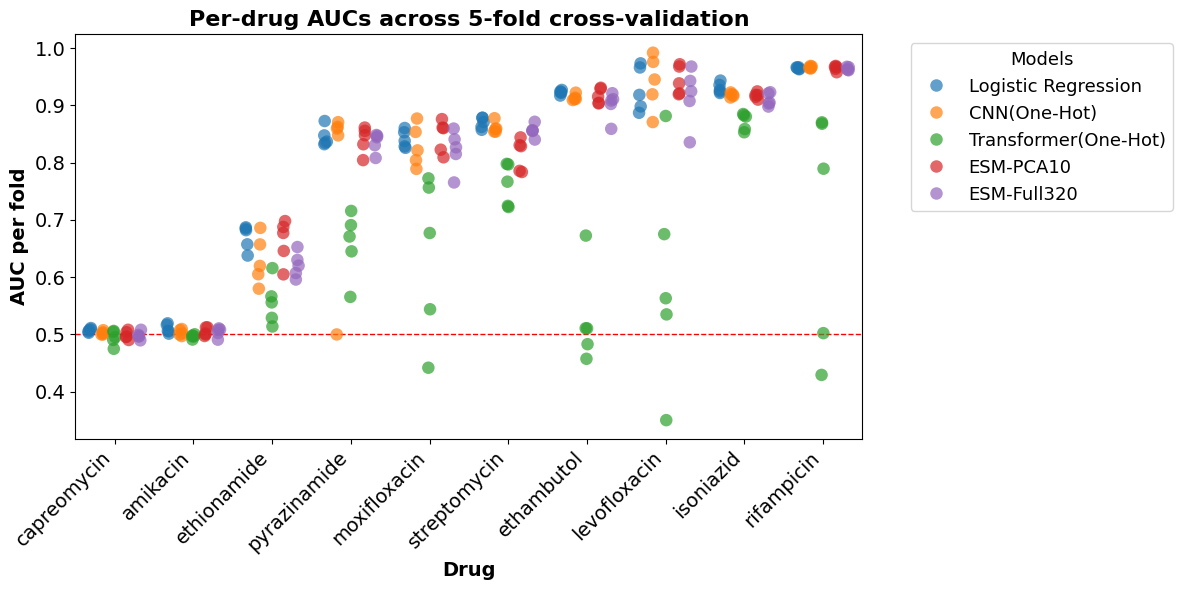

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load and filter cross-validation results ===
df = pd.read_csv("data/latest/cross_val/combined/all_fold_aucs.csv")

# Exclude linear baselines not used in final plot
df_plot = df[~df["model"].str.lower().isin(["lasso", "ridge"])].copy()

# === Rename models for display ===
name_map = {
    "CNN-320":   "ESM-Full320",
    "CNN-PCA10": "ESM-PCA10",
    "LogReg":    "Logistic Regression",
    "CNN":       "CNN(One-Hot)",
    "Transformer": "Transformer(One-Hot)"
}
df_plot["model"] = df_plot["model"].replace(name_map)

# === Define display order for models ===
model_order = [
    "Logistic Regression",
    "CNN(One-Hot)",
    "Transformer(One-Hot)",
    "ESM-PCA10",
    "ESM-Full320"
]
df_plot["model"] = pd.Categorical(df_plot["model"], categories=model_order, ordered=True)

# === Order drugs by mean AUC ===
drug_order = df_plot.groupby("drug")["auc"].mean().sort_values().index

# === Plot per-drug fold-level AUCs ===
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_plot,
    x="drug", y="auc",
    hue="model",
    order=drug_order, hue_order=model_order,
    dodge=True, jitter=True, alpha=0.7, size=9
)

# Reference line for random chance
plt.axhline(0.5, color="red", linestyle="--", lw=1)

# Axis styling
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Drug", fontsize=14, weight="bold")
plt.ylabel("AUC per fold", fontsize=14, weight="bold")
plt.title("Per-drug AUCs across 5-fold cross-validation", fontsize=16, weight="bold")

# Legend styling
plt.legend(
    title="Models",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=13,
    title_fontsize=13
)

# Save figure
plt.tight_layout()
plt.savefig("data/latest/cross_val/combined/per_drug_aucs_renamed.png", dpi=300)
plt.show()


In [19]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# ======================
# CONFIG
# ======================
MODEL_PATHS = {
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}

BASELINE_MODEL = "LogReg"

FOLD_RE = re.compile(r"(.+)_fold(\d+)_preds\.csv$", re.IGNORECASE)
SUFFIXES_TO_STRIP = ["_lasso", "_ridge", "_logreg"]

# ======================
# HELPERS
# ======================
def auc_safe(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def clean_drug_name(name):
    for s in SUFFIXES_TO_STRIP:
        if name.endswith(s):
            return name.replace(s, "")
    return name

def get_model_folds(path_pattern):
    """Return {drug: {fold: auc}}."""
    folds_dict = {}
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for f in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(f.name)
                if not m:
                    continue
                drug = clean_drug_name(m.group(1))
                fold = int(m.group(2))
                df = pd.read_csv(f)
                auc = auc_safe(df["label"], df["prob"])
                folds_dict.setdefault(drug, {})[fold] = auc
    return folds_dict

# ======================
# MAIN
# ======================
def main():
    # ---- Load all models ----
    all_model_data = {m: get_model_folds(p) for m, p in MODEL_PATHS.items()}

    rows = []

    for drug in sorted(all_model_data[BASELINE_MODEL].keys()):
        baseline_folds = all_model_data[BASELINE_MODEL][drug]
        for model, data in all_model_data.items():
            if drug not in data:
                continue

            folds = data[drug]
            common_folds = sorted(set(baseline_folds) & set(folds))
            aucs = np.array([folds[f] for f in common_folds])

            mean_auc = np.mean(aucs)
            sd_auc = np.std(aucs, ddof=1)
            ci_low = mean_auc - 1.96 * (sd_auc / np.sqrt(len(aucs)))
            ci_high = mean_auc + 1.96 * (sd_auc / np.sqrt(len(aucs)))

            # === statistical tests ===
            if model == BASELINE_MODEL:
                # one-sample Wilcoxon vs 0.5 (above-chance)
                try:
                    _, p_val = wilcoxon(aucs - 0.5, alternative="greater")
                except ValueError:
                    p_val = np.nan
            else:
                base_aucs = np.array([baseline_folds[f] for f in common_folds])
                try:
                    _, p_val = wilcoxon(aucs, base_aucs, alternative="two-sided")
                except ValueError:
                    p_val = np.nan

            rows.append({
                "drug": drug,
                "model": model,
                "mean_auc": mean_auc,
                "std_auc": sd_auc,
                "ci_95": f"[{ci_low:.3f},{ci_high:.3f}]",
                "p_value": p_val
            })

    # ---- Collect results ----
    df = pd.DataFrame(rows)

    # Benjamini–Hochberg correction (within each drug)
    df["p_adj"] = df.groupby("drug")["p_value"].transform(
        lambda x: multipletests(x, method="fdr_bh")[1]
    )

    df["significant"] = df["p_adj"] < 0.05
    df.to_csv("data/latest/cross_val/combined/per_drug_wilcoxon.csv", index=False)
    print(f"[OK] Wrote per_drug_wilcoxon.csv with {len(df)} rows.")

    # optional: summarize best model per drug
    winners = (
        df[df["model"] != BASELINE_MODEL]
        .sort_values(["drug", "mean_auc"], ascending=[True, False])
        .groupby("drug")
        .first()
        .reset_index()
    )
    winners.to_csv("data/latest/cross_val/combined/best_models_per_drug_wilcoxon.csv", index=False)
    print("[OK] Wrote best_models_per_drug_wilcoxon.csv.")

if __name__ == "__main__":
    main()


[OK] Wrote per_drug_wilcoxon.csv with 50 rows.
[OK] Wrote best_models_per_drug_wilcoxon.csv.


In [2]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon

# ======================
# CONFIG
# ======================
MODEL_PATHS = {
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}

BASELINE_MODEL = "LogReg"
FOLD_RE = re.compile(r"(.+)_fold(\d+)_preds\.csv$", re.IGNORECASE)
SUFFIXES_TO_STRIP = ["_lasso", "_ridge", "_logreg"]

# ======================
# HELPERS
# ======================
def auc_safe(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def clean_drug_name(name):
    for s in SUFFIXES_TO_STRIP:
        if name.endswith(s):
            return name.replace(s, "")
    return name

def get_model_folds(path_pattern):
    """Return {drug: {fold: auc}}."""
    folds_dict = {}
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for f in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(f.name)
                if not m:
                    continue
                drug = clean_drug_name(m.group(1))
                fold = int(m.group(2))
                df = pd.read_csv(f)
                auc = auc_safe(df["label"], df["prob"])
                folds_dict.setdefault(drug, {})[fold] = auc
    return folds_dict

# ======================
# MAIN
# ======================
def main():
    all_model_data = {m: get_model_folds(p) for m, p in MODEL_PATHS.items()}
    rows = []

    for drug in sorted(all_model_data[BASELINE_MODEL].keys()):
        baseline_folds = all_model_data[BASELINE_MODEL][drug]
        for model, data in all_model_data.items():
            if drug not in data:
                continue

            folds = data[drug]
            common_folds = sorted(set(baseline_folds) & set(folds))
            aucs = np.array([folds[f] for f in common_folds])

            mean_auc = np.mean(aucs)
            sd_auc = np.std(aucs, ddof=1)
            ci_low = mean_auc - 1.96 * (sd_auc / np.sqrt(len(aucs)))
            ci_high = mean_auc + 1.96 * (sd_auc / np.sqrt(len(aucs)))

            if model != BASELINE_MODEL:
                base_aucs = np.array([baseline_folds[f] for f in common_folds])
                try:
                    _, p_val = wilcoxon(aucs, base_aucs, alternative="two-sided")
                except ValueError:
                    p_val = np.nan
            else:
                p_val = np.nan  # no test for baseline vs itself

            rows.append({
                "drug": drug,
                "model": model,
                "mean_auc": mean_auc,
                "std_auc": sd_auc,
                "ci_95": f"[{ci_low:.3f},{ci_high:.3f}]",
                "p_vs_baseline": p_val
            })

    df = pd.DataFrame(rows)
    df.to_csv("data/latest/cross_val/combined/per_drug_wilcoxon_pairwise.csv", index=False)
    print(f"[OK] Wrote per_drug_wilcoxon_pairwise.csv with {len(df)} rows.")
    # optional: summarize best model per drug
    winners = (
        df[df["model"] != BASELINE_MODEL]
        .sort_values(["drug", "mean_auc"], ascending=[True, False])
        .groupby("drug")
        .first()
        .reset_index()
    )
    winners.to_csv("data/latest/cross_val/combined/best_models_per_drug_wilcoxon.csv", index=False)
    print("[OK] Wrote best_models_per_drug_wilcoxon.csv.")

if __name__ == "__main__":
    main()


[OK] Wrote per_drug_wilcoxon_pairwise.csv with 50 rows.
[OK] Wrote best_models_per_drug_wilcoxon.csv.


In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # copy & filter
# df_plot = df[~df["model"].str.lower().isin(["lasso", "ridge"])].copy()

# # rename models for display
# name_map = {
#     "CNN-320":   "ESM-Full320",
#     "CNN-PCA10": "ESM-PCA10",
#     "LogReg":    "Logistic Regression",
#     "CNN":      "CNN(One-Hot)",
#     "Transformer": "Transformer(One-Hot)"
# }
# df_plot["model"] = df_plot["model"].replace(name_map)

# # (optional) control legend/order
# model_order = [ "Logistic Regression","CNN(One-Hot)", "Transformer(One-Hot)" ,"ESM-PCA10","ESM-Full320"]
# df_plot["model"] = pd.Categorical(df_plot["model"], categories=model_order, ordered=True)

# # order drugs (optional)
# drug_order = df_plot.groupby("drug")["auc"].mean().sort_values().index

# plt.figure(figsize=(12,6))
# sns.stripplot(
#     data=df_plot, x="drug", y="auc", hue="model",
#     order=drug_order, hue_order=model_order,
#     dodge=True, jitter=True, alpha=0.7, size=10
# )

# plt.axhline(0.5, color="red", linestyle="--", lw=1)
# plt.xticks(rotation=45, ha="right", fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel("Drug", fontsize=14, weight="bold")
# plt.ylabel("AUC per fold", fontsize=14, weight="bold")
# plt.title("Per-drug AUCs across folds", fontsize=16, weight="bold")
# plt.legend(title="Models", bbox_to_anchor=(1.05,1), loc="upper left",
#            fontsize=14, title_fontsize=13)
# plt.tight_layout()
# plt.savefig("data/latest/cross_val/combined/per_drug_aucs_renamed.png", dpi=300)
# plt.show()


In [5]:
from itertools import combinations
from scipy.stats import ttest_rel
import pandas as pd

results = []

for drug, sub in df_plot.groupby("drug"):
    models = sub["model"].unique()
    for m1, m2 in combinations(models, 2):
        a1 = sub[sub["model"] == m1].sort_values("fold")["auc"].values
        a2 = sub[sub["model"] == m2].sort_values("fold")["auc"].values
        if len(a1) == len(a2):  # ensure paired folds
            t_stat, p_val = ttest_rel(a1, a2)
            results.append({
                "drug": drug,
                "model_1": m1,
                "model_2": m2,
                "mean_diff": a1.mean() - a2.mean(),
                "p_value": p_val
            })

compare_df = pd.DataFrame(results)
compare_df["significant"] = compare_df["p_value"] < 0.05
compare_df.to_csv("data/latest/cross_val/paired_ttests_per_drug.csv", index=False)


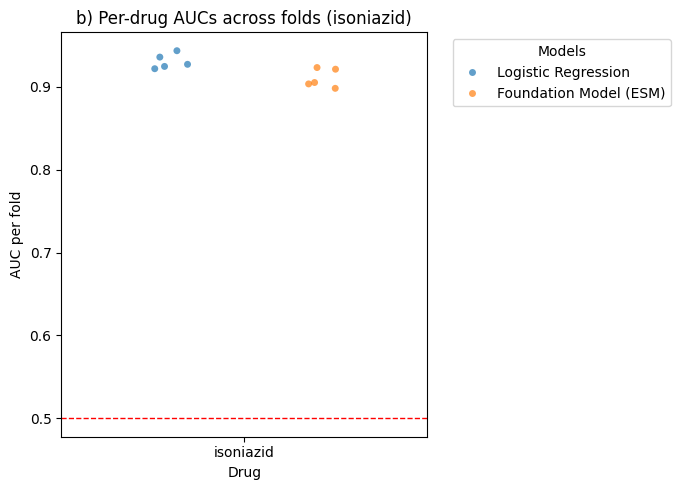

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- filter to just isoniazid + keep only desired models ---
df_plot = df.copy()
df_plot["model_norm"] = df_plot["model"].str.lower().str.strip()

keep_models = {"cnn-320", "logreg"}
df_plot = df_plot[
    (df_plot["drug"].str.lower() == "isoniazid") &
    (df_plot["model_norm"].isin(keep_models))
]

# --- rename 'cnn-320' -> 'esm-320' for display; normalize logistic label ---
display_map = {
    "cnn-320": "Foundation Model (ESM)",
    "logreg": "Logistic Regression",
}
df_plot["model_display"] = df_plot["model_norm"].map(display_map)

# --- plot (single-drug) ---
plt.figure(figsize=(7,5))
sns.stripplot(
    data=df_plot,
    x="drug", y="auc", hue="model_display",
    order=["isoniazid"], dodge=True, jitter=True, alpha=0.7
)

plt.axhline(0.5, color="red", linestyle="--", lw=1)
plt.xticks(rotation=0)
plt.xlabel("Drug")
plt.ylabel("AUC per fold")
plt.title("b) Per-drug AUCs across folds (isoniazid)")
plt.legend(title="Models", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


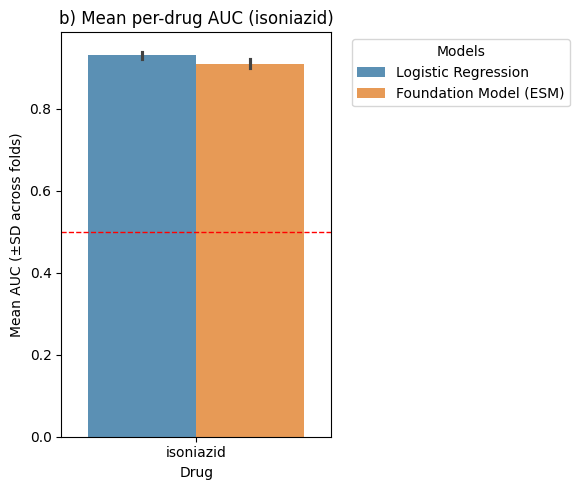

In [12]:
plt.figure(figsize=(6,5))
sns.barplot(
    data=df_plot,
    x="drug", y="auc", hue="model_display",
    order=["isoniazid"], errorbar="sd",  # or "ci" for confidence intervals
    alpha=0.8
)

plt.axhline(0.5, color="red", linestyle="--", lw=1)
plt.xlabel("Drug")
plt.ylabel("Mean AUC (±SD across folds)")
plt.title("b) Mean per-drug AUC (isoniazid)")
plt.legend(title="Models", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
from io import StringIO

# raw text for the DNA results
dna_text = """drug,model,fold,auc,model_display
isoniazid,LogReg,1,0.9769466466645472,Logistic Regression
isoniazid,LogReg,2,0.9642164989756136,Logistic Regression
isoniazid,LogReg,3,0.9638325244882621,Logistic Regression
isoniazid,LogReg,4,0.9701485889395668,Logistic Regression
isoniazid,LogReg,5,0.9690207461298253,Logistic Regression
isoniazid,DNABERT-CNN-768,1,0.8828876042720213,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,2,0.8423,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,3,0.863242,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,4,0.85213,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,5,0.872312,DNABERT-CNN-768
"""

# read into DataFrame
df_dna = pd.read_csv(StringIO(dna_text))

# add a 'source' column so it can be combined with protein data
df_dna["source"] = "DNA"

print(df_dna)


        drug            model  fold       auc        model_display source
0  isoniazid           LogReg     1  0.976947  Logistic Regression    DNA
1  isoniazid           LogReg     2  0.964216  Logistic Regression    DNA
2  isoniazid           LogReg     3  0.963833  Logistic Regression    DNA
3  isoniazid           LogReg     4  0.970149  Logistic Regression    DNA
4  isoniazid           LogReg     5  0.969021  Logistic Regression    DNA
5  isoniazid  DNABERT-CNN-768     1  0.882888      DNABERT-CNN-768    DNA
6  isoniazid  DNABERT-CNN-768     2  0.842300      DNABERT-CNN-768    DNA
7  isoniazid  DNABERT-CNN-768     3  0.863242      DNABERT-CNN-768    DNA
8  isoniazid  DNABERT-CNN-768     4  0.852130      DNABERT-CNN-768    DNA
9  isoniazid  DNABERT-CNN-768     5  0.872312      DNABERT-CNN-768    DNA


/scratch/login/ipykernel_3131098/3471555860.py:51: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


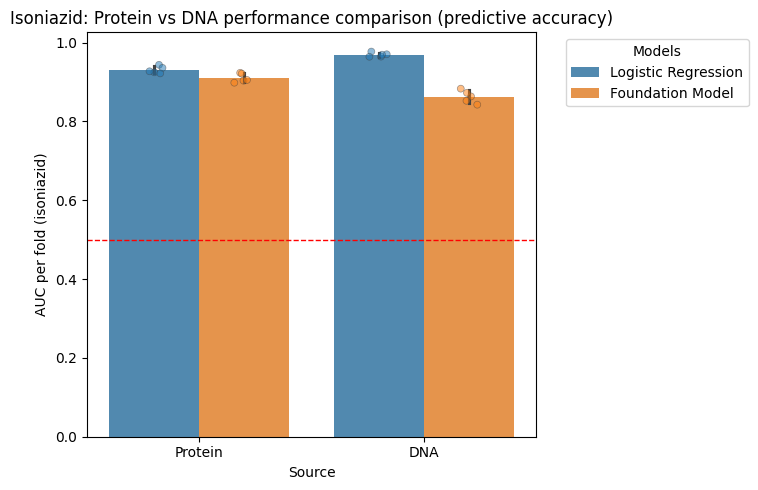

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO

# ---------- Protein ----------
df_protein_plot = df_plot.copy()
df_protein_plot["source"] = "Protein"

def to_family_label(name: str) -> str:
    n = str(name).lower().strip()
    if n in {"cnn-320", "dnabert-cnn-768"}:
        return "Foundation Model"
    if n in {"logreg"}:
        return "Logistic Regression"
    return name  # fallback

df_protein_plot["model_display"] = df_protein_plot["model_norm"].apply(to_family_label)

# ---------- DNA (from your CSV text) ----------
dna_text = """drug,model,fold,auc,model_display
isoniazid,LogReg,1,0.9769466466645472,Logistic Regression
isoniazid,LogReg,2,0.9642164989756136,Logistic Regression
isoniazid,LogReg,3,0.9638325244882621,Logistic Regression
isoniazid,LogReg,4,0.9701485889395668,Logistic Regression
isoniazid,LogReg,5,0.9690207461298253,Logistic Regression
isoniazid,DNABERT-CNN-768,1,0.8828876042720213,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,2,0.8423,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,3,0.863242,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,4,0.85213,DNABERT-CNN-768
isoniazid,DNABERT-CNN-768,5,0.872312,DNABERT-CNN-768
"""
df_dna_plot = pd.read_csv(StringIO(dna_text))
df_dna_plot["source"] = "DNA"

# unify display names to the same two families
df_dna_plot["model_display"] = df_dna_plot["model"].apply(to_family_label)

# ---------- Combine & plot ----------
df_combined = pd.concat([df_protein_plot, df_dna_plot], ignore_index=True)

plt.figure(figsize=(7.5,5))
sns.barplot(
    data=df_combined,
    x="source", y="auc", hue="model_display",
    order=["Protein", "DNA"],
    hue_order=["Logistic Regression", "Foundation Model"],
    errorbar="sd", alpha=0.85
)
sns.stripplot(
    data=df_combined,
    x="source", y="auc", hue="model_display",
    order=["Protein", "DNA"],
    hue_order=["Logistic Regression", "Foundation Model"],
    dodge=True, jitter=True, alpha=0.5,
    marker="o", linewidth=0.5, edgecolor="gray",
    legend=False  # avoid duplicate legend
)

plt.axhline(0.5, color="red", linestyle="--", lw=1)
plt.xlabel("Source")
plt.ylabel("AUC per fold (isoniazid)")
plt.title("Isoniazid: Protein vs DNA performance comparison (predictive accuracy)")
plt.legend(title="Models", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

# group by Source + Model and compute mean and SD
summary = (
    df_combined
    .groupby(["source", "model_display"])["auc"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values(["source", "model_display"])
)

print(summary)

    source        model_display      mean       std  count
0      DNA     Foundation Model  0.862574  0.016031      5
1      DNA  Logistic Regression  0.968833  0.005337      5
2  Protein     Foundation Model  0.910128  0.011257      5
3  Protein  Logistic Regression  0.930451  0.008943      5


In [14]:
df_combined

,drug,model,fold,auc,line_group,model_norm,model_display,source
0,isoniazid,LogReg,1,0.924456,First line,logreg,Logistic Regression,Protein
1,isoniazid,LogReg,2,0.926992,First line,logreg,Logistic Regression,Protein
2,isoniazid,LogReg,3,0.943403,First line,logreg,Logistic Regression,Protein
3,isoniazid,LogReg,4,0.935706,First line,logreg,Logistic Regression,Protein
4,isoniazid,LogReg,5,0.921696,First line,logreg,Logistic Regression,Protein
5,isoniazid,CNN-320,1,0.923103,First line,cnn-320,Foundation Model,Protein
6,isoniazid,CNN-320,2,0.921105,First line,cnn-320,Foundation Model,Protein
7,isoniazid,CNN-320,3,0.898031,First line,cnn-320,Foundation Model,Protein
8,isoniazid,CNN-320,4,0.903358,First line,cnn-320,Foundation Model,Protein
9,isoniazid,CNN-320,5,0.905043,First line,cnn-320,Foundation Model,Protein


## precision recall

In [ ]:
# pr_from_shap.py
# ------------------------------------------------------------
import pandas as pd, numpy as np
from pathlib import Path
from functools import reduce

# ─── 0. Global knobs ---------------------------------------------------
K_VALUES      = [1, 5, 10]
ALLOWED_CONF  = ['1) Assoc w R', '2) Assoc w R - Interim']

DATA_DIR      = Path("data")                                # root
CATALOG_CSV   = DATA_DIR / "filtered_variants_output.csv"

# ─── 0-b.  Drug → genes map (same map  train with) -----------------
DRUG2GENES = {
    "rifampicin"  : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"],
    "moxifloxacin": ["gyrA","gyrB"],
    "levofloxacin": ["gyrA","gyrB"],
    "isoniazid"   : ["katG","inhA"],
    "streptomycin": ["rpsL","gid"],
    "ethambutol"  : ["embC","embA","embB"],   # corrected order
    "ethionamide" : ["ethA","ethR","inhA"],
}

# ─── 1. Load WHO catalogue once ---------------------------------------
catalog = pd.read_csv(CATALOG_CSV)
catalog["aa_pos_0idx"] = catalog["aa_pos"].astype(int) - 1  # zero-based

def bona_fide(cat_rows):
    m = cat_rows["confidence"].isin(ALLOWED_CONF) & (cat_rows["intersectional"] == True)
    return set(cat_rows.loc[m, "aa_pos_0idx"])

# def exclusion(cat_rows):
#     m = (cat_rows["confidence"] == "3) Uncertain significance") | (cat_rows["intersectional"] != True)
#     return set(cat_rows.loc[m, "aa_pos_0idx"])
def exclusion(cat_rows):
    mask_unc   = cat_rows["confidence"] == "3) Uncertain significance"
    mask_not_i = cat_rows["intersectional"] != True
    excl = set(cat_rows.loc[mask_unc | mask_not_i, "aa_pos_0idx"])
    return excl - bona_fide(cat_rows)          # ← keep bona-fide sites

def rows_for_gene(g):   # convenience
    return catalog[catalog["gene"].str.lower() == g.lower()]

# ─── 2. helper: rank residues by max|SHAP| across isolates -------------
def rank_by_max_abs(shap_df, col):
    stacks = np.stack([np.asarray(v).squeeze() for v in shap_df[col]], axis=0)  # (N,L)
    maximp = np.abs(stacks).max(axis=0)
    return (pd.DataFrame({"Residue_Position": np.arange(len(maximp)),
                          "MaxAbsSHAP": maximp})
            .sort_values("MaxAbsSHAP", ascending=False)
            .reset_index(drop=True))

def greedy_topk(rank_df, k, exclude):
    chosen=[]
    for pos in rank_df["Residue_Position"]:
        if pos in exclude:   # skip excluded sites
            continue
        chosen.append(pos)
        if len(chosen)==k:
            break
    return chosen



In [ ]:
from pathlib import Path
import numpy as np, pandas as pd

# ---- CV lat root ----
CV_ROOT = Path("data/latest/cross_val/esm_cv_sig")
MODES   = ["full", "pca"]   # keep only those  have

def _per_fold_pr(drug:str, genes:list, shap_df:pd.DataFrame, fold_dir:Path):
    """
    Uses  exact helpers:
      - rank_by_max_abs(shap_df, col)
      - rows_for_gene(g), bona_fide(...), exclusion(...)
      - K_VALUES, ALLOWED_CONF (already defined above)
    Writes per-gene ranked SHAP and per-gene PR tables into fold_dir.
    Also writes one combined PR CSV for the fold.
    """
    per_fold_rows = []
    for g in genes:
        # choose the SHAP column name
        col_name = f"importance_{g}" if len(genes)>1 else "importance_full"
        if col_name not in shap_df.columns:
            print(f"[warn] {drug} {fold_dir.name}: {col_name} not found — skipping {g}")
            continue

        # 1) ranked SHAP per gene ( logic)
        rank_df = rank_by_max_abs(shap_df, col_name)

        # save per-fold per-gene ranked CSV right under fold dir
        out_rank = fold_dir / f"{drug}_{g}_ranked_SHAP.csv"
        rank_df.to_csv(out_rank, index=False)
        print(f"[ok] ranked SHAP → {out_rank}")

        # 2) per-fold PR ( logic)
        cat_rows   = rows_for_gene(g)
        gold_sites = bona_fide(cat_rows)
        excl_sites = exclusion(cat_rows)
        n_true     = len(gold_sites)

        for k in K_VALUES:
            topk   = greedy_topk(rank_df, k, exclude=excl_sites)
            k_eff  = len(topk)
            tp     = len(gold_sites & set(topk))
            prec   = tp / k_eff if k_eff else 0.0
            rec    = tp / n_true if n_true else 0.0
            f1     = 2*prec*rec/(prec+rec+1e-8) if (prec+rec) else 0.0

            hits = (cat_rows[
                        cat_rows["aa_pos_0idx"].isin(topk) &
                        cat_rows["confidence"].isin(ALLOWED_CONF) &
                        (cat_rows["intersectional"] == True)
                    ]
                    .drop_duplicates("aa_pos_0idx")["variant"].tolist() or ["None"])

            per_fold_rows.append({
                "drug": drug, "gene": g, "fold": fold_dir.name,
                "k_req": k, "k_eff": k_eff,
                "total_res_pos": n_true, "TP": tp,
                "precision": prec, "recall": rec, "F1": f1,
                "hit_variants": ", ".join(hits)
            })

        # also write a per-gene PR table for this fold (optional but handy)
        pr_gene_df = pd.DataFrame([r for r in per_fold_rows if r["gene"]==g and r["fold"]==fold_dir.name])
        pr_gene_out = fold_dir / f"{drug}_{g}_precision_recall.csv"
        pr_gene_df.to_csv(pr_gene_out, index=False)
        print(f"[ok] PR per gene → {pr_gene_out}")

    # fold-level combined PR table
    if per_fold_rows:
        pr_fold_df = pd.DataFrame(per_fold_rows)
        pr_fold_out = fold_dir / f"{Path(fold_dir).parent.parent.name}_{Path(fold_dir).parent.name}_{fold_dir.name}_precision_recall_ALL_GENES.csv"
        pr_fold_df.to_csv(pr_fold_out, index=False)
        print(f"[ok] PR (all genes, this fold) → {pr_fold_out}")

# ---------- iterate CV tree and apply  code per fold ----------
for drug_dir in sorted([d for d in CV_ROOT.iterdir() if d.is_dir()]):
    drug = drug_dir.name
    genes = DRUG2GENES.get(drug)
    if not genes:
        print(f"[skip] {drug}: not in DRUG2GENES")
        continue

    for mode in MODES:
        mode_dir = drug_dir / mode
        if not mode_dir.is_dir():
            continue

        for fold_dir in sorted([d for d in mode_dir.iterdir() if d.is_dir() and d.name.startswith("fold_")]):
            pkls = list(fold_dir.glob("*_shap_per_residue.pkl"))
            if not pkls:
                print(f"[skip] no SHAP pickle in {fold_dir}")
                continue
            if len(pkls) > 1:
                print(f"[info] multiple shap pkls in {fold_dir}, using: {pkls[0].name}")
            pkl = pkls[0]

            # load once, then apply  exact logic
            shap_df = pd.read_pickle(pkl)
            _per_fold_pr(drug, genes, shap_df, fold_dir)


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd

# ---- CV lat root ----
CV_ROOT = Path("data/latest/cross_val/cnn_cv_sig")

# ---------- iterate CV tree and apply  code per fold ----------
for drug_dir in sorted([d for d in CV_ROOT.iterdir() if d.is_dir()]):
    drug = drug_dir.name
    genes = DRUG2GENES.get(drug)
    if not genes:
        print(f"[skip] {drug}: not in DRUG2GENES")
        continue

    for fold_dir in sorted([d for d in drug_dir.iterdir() if d.is_dir() and d.name.startswith("fold_")]):
        pkls = list(fold_dir.glob("*_shap.pkl"))
        if not pkls:
            print(f"[skip] no SHAP pickle in {fold_dir}")
            continue
        if len(pkls) > 1:
            print(f"[info] multiple shap pkls in {fold_dir}, using: {pkls[0].name}")
        pkl = pkls[0]

        # load once, then apply  exact logic
        shap_df = pd.read_pickle(pkl)
        imp_cols = [c for c in shap_df.columns if c.startswith("importance")]
        print(f"[dbg] {drug} {fold_dir.name} importance cols: {imp_cols[:8]}{'...' if len(imp_cols)>8 else ''}")

        _per_fold_pr(drug, genes, shap_df, fold_dir)


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd

# ---- CV lat root ----
CV_ROOT = Path("data/latest/cross_val/transformer_cv_sig")

# ---------- iterate CV tree and apply  code per fold ----------
for drug_dir in sorted([d for d in CV_ROOT.iterdir() if d.is_dir()]):
    drug = drug_dir.name
    genes = DRUG2GENES.get(drug)
    if not genes:
        print(f"[skip] {drug}: not in DRUG2GENES")
        continue

    for fold_dir in sorted([d for d in drug_dir.iterdir() if d.is_dir() and d.name.startswith("fold_")]):
        pkls = list(fold_dir.glob("*_shap_per_residue.pkl"))
        if not pkls:
            print(f"[skip] no SHAP pickle in {fold_dir}")
            continue
        if len(pkls) > 1:
            print(f"[info] multiple shap pkls in {fold_dir}, using: {pkls[0].name}")
        pkl = pkls[0]

        # load once, then apply  exact logic
        shap_df = pd.read_pickle(pkl)
        _per_fold_pr(drug, genes, shap_df, fold_dir)


In [ ]:
import os
# from pathlib import Path

# # Change this to the folder  want to clean
# TARGET_DIR = Path("data/latest/cross_val/esm_cv_sig")

# patterns = ["SHAP", "precision_recall"]

# deleted_files = []

# for path in TARGET_DIR.rglob("*.csv"):
#     fname_lower = path.name.lower()
#     if any(pat.lower() in fname_lower for pat in patterns):
#         try:
#             path.unlink()
#             deleted_files.append(str(path))
#         except Exception as e:
#             print(f"Failed to delete {path}: {e}")

# # print(f"Deleted {len(deleted_files)} files:")
# for f in deleted_files:
#     print(f"  {f}")


In [ ]:
# === PART A: CONFIG & MODEL SPECS ===
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import hypergeom

WHO_CSV = "data/filtered_variants_output.csv"

# Roots that match  lat
CV_ROOT  = "data/latest/cross_val"            # cnn / transformer
ESM_ROOT = "data/latest/cross_val/esm_cv_sig"           # esm/<full|pca>
REG_ROOT = "data/latest/cross_val/regression_cv_sig"    # lasso / ridge / logreg

for root, name in [(CV_ROOT,"CV_ROOT"), (ESM_ROOT,"ESM_ROOT"), (REG_ROOT,"REG_ROOT")]:
    print(f"[check] {name} -> {os.path.abspath(root)} exists? {os.path.isdir(root)}")


# Which models to run
MODELS_TO_RUN = [
    "cnn",
    "transformer",
    "esm_full",
    "esm_pca",
    "lasso",
    "ridge",
    "logreg",
]

K_MAX_DEFAULT = 200   # max k for TP(k)/recall(k)
N_BOOT        = 2000  # bootstrap reps across folds
RANDOM_SEED   = 42

# Model-specific file patterns + parsers
MODEL_SPECS = {
    # cross_val\[model]_cv_sig\[drug]\fold_[fold]\[drug]_[gene]_ranked_SHAP.csv
    "cnn": {
        "family": "shap",
        "glob": lambda drug: os.path.join(CV_ROOT, "cnn_cv_sig", drug, "fold_*", f"{drug}_*_ranked_SHAP.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"[\\/](?P<drug>[^_\\/]+)_(?P<gene>[^_\\/]+)_ranked_SHAP\.csv$", re.IGNORECASE),
    },
    "transformer": {
        "family": "shap",
        "glob": lambda drug: os.path.join(CV_ROOT, "transformer_cv_sig", drug, "fold_*", f"{drug}_*_ranked_SHAP.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"[\\/](?P<drug>[^_\\/]+)_(?P<gene>[^_\\/]+)_ranked_SHAP\.csv$", re.IGNORECASE),
    },

    # esm_cv_sig\[drug]\(full|pca)\fold_[fold]\[drug]_[gene]_ranked_SHAP.csv
    "esm_full": {
        "family": "shap",
        "glob": lambda drug: os.path.join(ESM_ROOT, drug, "full", "fold_*", f"{drug}_*_ranked_SHAP.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"[\\/](?P<drug>[^_\\/]+)_(?P<gene>[^_\\/]+)_ranked_SHAP\.csv$", re.IGNORECASE),
    },
    "esm_pca": {
        "family": "shap",
        "glob": lambda drug: os.path.join(ESM_ROOT, drug, "pca", "fold_*", f"{drug}_*_ranked_SHAP.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"[\\/](?P<drug>[^_\\/]+)_(?P<gene>[^_\\/]+)_ranked_SHAP\.csv$", re.IGNORECASE),
    },

    # regression_cv_sig\[drug]\[variant]\fold_[fold]
    # full_residue_scores_[gene]_[drug]_[variant]_fold[fold].csv
    "lasso": {
        "family": "reg",
        "variant": "lasso",
        "glob": lambda drug: os.path.join(REG_ROOT, drug, "lasso", "fold_*", f"full_residue_scores_*_{drug}_lasso_fold*.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"full_residue_scores_(?P<gene>[^_]+)_(?P<drug>[^_]+)_(?P<variant>[^_]+)_fold(?P<fold>\d+)\.csv$", re.IGNORECASE),
    },
    "ridge": {
        "family": "reg",
        "variant": "ridge",
        "glob": lambda drug: os.path.join(REG_ROOT, drug, "ridge", "fold_*", f"full_residue_scores_*_{drug}_ridge_fold*.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"full_residue_scores_(?P<gene>[^_]+)_(?P<drug>[^_]+)_(?P<variant>[^_]+)_fold(?P<fold>\d+)\.csv$", re.IGNORECASE),
    },
    "logreg": {
        "family": "reg",
        "variant": "logreg",
        "glob": lambda drug: os.path.join(REG_ROOT, drug, "logreg", "fold_*", f"full_residue_scores_*_{drug}_logreg_fold*.csv"),
        "fold_regex": re.compile(r"[\\/ ]fold_(\d+)[\\/ ]", re.IGNORECASE),
        "gene_drug_regex": re.compile(r"full_residue_scores_(?P<gene>[^_]+)_(?P<drug>[^_]+)_(?P<variant>[^_]+)_fold(?P<fold>\d+)\.csv$", re.IGNORECASE),
    },
}

def infer_drugs_from_model(model_key):
    if model_key in ("cnn", "transformer"):
        root = os.path.join(CV_ROOT, f"{model_key}_cv_sig")
        return sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]) if os.path.isdir(root) else []
    if model_key in ("esm_full", "esm_pca"):
        return sorted([d for d in os.listdir(ESM_ROOT) if os.path.isdir(os.path.join(ESM_ROOT, d))]) if os.path.isdir(ESM_ROOT) else []
    if model_key in ("lasso", "ridge", "logreg"):
        return sorted([d for d in os.listdir(REG_ROOT) if os.path.isdir(os.path.join(REG_ROOT, d))]) if os.path.isdir(REG_ROOT) else []
    return []


[check] CV_ROOT -> /work/pi_annagreen_umass_edu/mahbuba/protein-tasks/data/latest/cross_val exists? True
[check] ESM_ROOT -> /work/pi_annagreen_umass_edu/mahbuba/protein-tasks/data/latest/cross_val/esm_cv_sig exists? True
[check] REG_ROOT -> /work/pi_annagreen_umass_edu/mahbuba/protein-tasks/data/latest/cross_val/regression_cv_sig exists? True


In [ ]:
# At top with  knobs:
ALLOWED_CONF = {'1) Assoc w R', '2) Assoc w R - Interim'}

def _who_gold_rows(who_df, drug, genes=None):
    sub = who_df.copy()
    sub["drug_norm"] = sub["drug"].astype(str).str.lower().str.strip()
    sub["gene_norm"] = sub["gene"].astype(str).str.lower().str.strip()
    m = (sub["drug_norm"] == str(drug).lower().strip()) \
        & (sub["confidence"].isin(ALLOWED_CONF)) \
        & (sub["intersectional"] == True)
    if genes is not None:
        genes_norm = {g.lower().strip() for g in genes}
        m &= sub["gene_norm"].isin(genes_norm)
    return sub.loc[m, ["gene_norm", "aa_pos"]].drop_duplicates()

def _who_excl_rows(who_df, drug, genes=None):
    """Uncertain OR not-intersectional, minus any gold rows (belt & suspenders)."""
    sub = who_df.copy()
    sub["drug_norm"] = sub["drug"].astype(str).str.lower().str.strip()
    sub["gene_norm"] = sub["gene"].astype(str).str.lower().str.strip()
    m = (sub["drug_norm"] == str(drug).lower().strip())
    if genes is not None:
        genes_norm = {g.lower().strip() for g in genes}
        m &= sub["gene_norm"].isin(genes_norm)
    sub = sub.loc[m, ["gene_norm", "aa_pos", "confidence", "intersectional"]].drop_duplicates()

    mask_unc   = sub["confidence"].astype(str).eq("3) Uncertain significance")
    mask_not_i = sub["intersectional"] != True
    excl = sub.loc[mask_unc | mask_not_i, ["gene_norm", "aa_pos"]]

    gold = _who_gold_rows(who_df, drug, genes)
    if not gold.empty:
        excl = excl.merge(gold, on=["gene_norm", "aa_pos"], how="left", indicator=True)
        excl = excl[excl["_merge"] == "left_only"].drop(columns="_merge")
    return set(zip(excl["gene_norm"], excl["aa_pos"].astype(int)))


In [3]:
# === PART B: HELPERS ===

def infer_position_and_score_columns(df: pd.DataFrame):
    """
    Case-insensitive inference.
    - Position: prefer 0-index (common in SHAP/reg files), else 1-index.
    - Score: SHAP uses MaxAbsSHAP; regression uses Importance; fallback to a numeric col.
    """
    lower_to_orig = {c.lower(): c for c in df.columns}

    pos0_keys = ["residue_position", "res_pos", "position", "pos0"]
    pos1_keys = ["aa_pos", "pos", "position_aa", "pos1"]

    pos_col, pos_is_1idx = None, False
    for key in pos0_keys:
        if key in lower_to_orig: pos_col = lower_to_orig[key]; pos_is_1idx = False; break
    if pos_col is None:
        for key in pos1_keys:
            if key in lower_to_orig: pos_col = lower_to_orig[key]; pos_is_1idx = True; break
    if pos_col is None:
        raise ValueError(f"Cannot infer residue position column from {list(df.columns)}")

    score_keys = ["maxabsshap", "importance", "score", "saliency", "coef_abs", "abs_coef", "coef", "weight", "value"]
    score_col = None
    for key in score_keys:
        if key in lower_to_orig: score_col = lower_to_orig[key]; break

    if score_col is None:
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        for drop in [pos_col, "Fold", "fold"]:
            if drop in numeric_cols:
                numeric_cols.remove(drop)
        if numeric_cols:
            score_col = max(numeric_cols, key=lambda c: float(pd.to_numeric(df[c], errors="coerce").var()))
        else:
            raise ValueError(f"Cannot infer score column from {list(df.columns)}")

    return pos_col, score_col, pos_is_1idx

def parse_gene_and_fold_from_path(model_key, drug, path):
    spec = MODEL_SPECS[model_key]
    mfold = spec["fold_regex"].search(path)
    fold_from_path = int(mfold.group(1)) if mfold else 0

    mgd = spec["gene_drug_regex"].search(path)
    gene_from_path = mgd.groupdict().get("gene") if mgd else None
    return gene_from_path, fold_from_path

def collect_rankings_for_drug_model(drug, model_key):
    """
    Returns:
      fold_to_df: {fold -> DataFrame[gene, aa_pos(1-index), score] sorted desc}
      universe:   set of (gene, aa_pos)
      genes_seen: list of genes encountered
    """
    spec = MODEL_SPECS[model_key]
    files = glob.glob(spec["glob"](drug))
    if not files:
        return {}, set(), []

    fold_chunks_map = defaultdict(list)
    genes_seen = set()

    for f in files:
        gene, fold = parse_gene_and_fold_from_path(model_key, drug, f)

        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"[warn] read failure: {f} -> {e}"); continue

        # Prefer Gene/Fold columns if present
        if "Gene" in df.columns and pd.Series(df["Gene"]).nunique() == 1:
            gene = str(df["Gene"].iloc[0])
        if "Fold" in df.columns:
            try: fold = int(df["Fold"].iloc[0])
            except: pass

        try:
            pos_col, score_col, pos_is_1idx = infer_position_and_score_columns(df)
        except Exception as e:
            print(f"[warn] infer columns failed for {f}: {e}"); continue

        pos = pd.to_numeric(df[pos_col], errors="coerce").astype("Int64").dropna().astype(int)
        aa_pos = pos if pos_is_1idx else (pos + 1)

        score_series = pd.to_numeric(df[score_col], errors="coerce").fillna(0.0)
        if spec["family"] == "reg":
            score_series = score_series.abs()

        chunk = pd.DataFrame({"gene": gene, "aa_pos": aa_pos, "score": score_series})
        fold_chunks_map[fold].append(chunk)
        if gene is not None:
            genes_seen.add(gene)

    fold_to_df, universe = {}, set()
    for fold, chunks in fold_chunks_map.items():
        if not chunks: continue
        comb = pd.concat(chunks, ignore_index=True)
        comb = comb.groupby(["gene", "aa_pos"], as_index=False)["score"].max()
        comb = comb.sort_values("score", ascending=False).reset_index(drop=True)
        fold_to_df[fold] = comb
        universe.update(set(zip(comb["gene"], comb["aa_pos"])))

    return fold_to_df, universe, sorted(genes_seen)

# def who_hits_for_drug_subset(who_df, drug, genes_seen, universe):
#     # normalize gene names on both sides
#     genes_seen_norm = {str(g).lower().strip() for g in genes_seen if pd.notna(g)}
#     sub = who_df.copy()

#     # *** use .str.lower().str.strip() (NOT .lower().strip()) ***
#     sub["drug_norm"] = sub["drug"].astype(str).str.lower().str.strip()
#     sub["gene_norm"] = sub["gene"].astype(str).str.lower().str.strip()

#     sub = sub[(sub["drug_norm"] == str(drug).lower().strip()) &
#               (sub["gene_norm"].isin(genes_seen_norm))]

#     hits_norm = set(zip(sub["gene_norm"], sub["aa_pos"].astype(int)))
#     universe_norm = {(str(g).lower().strip(), int(p)) for (g, p) in universe}
#     return hits_norm.intersection(universe_norm)

def who_hits_for_drug_subset(who_df, drug, genes_seen, universe):
    gold = _who_gold_rows(who_df, drug, genes_seen)
    gold_hits_norm = set(zip(gold["gene_norm"], gold["aa_pos"].astype(int)))
    universe_norm  = {(str(g).lower().strip(), int(p)) for (g, p) in universe}
    return gold_hits_norm.intersection(universe_norm)

def who_exclusions_for_drug_subset(who_df, drug, genes_seen):
    return _who_excl_rows(who_df, drug, genes_seen)

def tp_curve_for_fold(ranking_df, who_hits_norm, k_max):
    K = len(who_hits_norm)
    if K == 0:
        return pd.DataFrame({"k": [], "TP_k": [], "recall_k": []})

    n = min(k_max, len(ranking_df))
    top = ranking_df.head(n).copy()

    # normalize gene strings inline for membership check
    top["_gene_norm"] = top["gene"].astype(str).str.lower().str.strip()
    top["_is_hit"] = list(zip(top["_gene_norm"], top["aa_pos"].astype(int)))
    is_hit = top["_is_hit"].apply(lambda x: x in who_hits_norm).astype(int)

    tp_cum = is_hit.cumsum().to_numpy()
    k_vals = np.arange(1, n + 1)
    recall = tp_cum / float(K)
    return pd.DataFrame({"k": k_vals, "TP_k": tp_cum, "recall_k": recall})


def bootstrap_mean_ci(values_2d, n_boot=2000, seed=42, ci=(2.5, 97.5)):
    rng = np.random.default_rng(seed)
    n_reps, n_k = values_2d.shape
    means = values_2d.mean(axis=0)
    boots = np.empty((n_boot, n_k))
    for b in range(n_boot):
        idx = rng.integers(0, n_reps, size=n_reps)
        boots[b, :] = values_2d[idx, :].mean(axis=0)
    lo = np.percentile(boots, ci[0], axis=0)
    hi = np.percentile(boots, ci[1], axis=0)
    return means, lo, hi

def random_baseline(L, K, k_array):
    exp = k_array * (K / float(L))
    lo = hypergeom.ppf(0.025, L, K, k_array)
    hi = hypergeom.ppf(0.975, L, K, k_array)
    return exp, lo, hi


In [ ]:
# === PART C: MAIN: plot rank–recovery per (model, drug) ===
def plot_rank_recovery(model_keys=MODELS_TO_RUN, drugs=None,
                       k_max_default=K_MAX_DEFAULT, who_csv=WHO_CSV,
                       n_boot=N_BOOT, seed=RANDOM_SEED):
    who_df = pd.read_csv(who_csv)

    for model_key in model_keys:
        all_drugs = drugs or infer_drugs_from_model(model_key)
        if not all_drugs:
            print(f"[{model_key}] No drugs found."); 
            continue

        for drug in all_drugs:
            # 1) Load per-fold rankings
            fold_to_df, universe, genes_seen = collect_rankings_for_drug_model(drug, model_key)
            if not fold_to_df:
                print(f"[{model_key} | {drug}] No fold data, skipping.")
                continue

            # 2) Exclusions (uncertain OR not-intersectional) for this drug+genes_seen
            excl_norm = who_exclusions_for_drug_subset(who_df, drug, genes_seen)

            # 3) Filter each fold's ranking to drop excluded (gene,pos) pairs
            filtered_fold_to_df = {}
            allowed_universe_norm = set()
            for fold, df in fold_to_df.items():
                tmp = df.copy()
                tmp["_gene_norm"] = tmp["gene"].astype(str).str.lower().str.strip()
                pairs = list(zip(tmp["_gene_norm"].to_numpy(),
                                 tmp["aa_pos"].astype(int).to_numpy()))
                keep = [pair not in excl_norm for pair in pairs]
                tmp = tmp.loc[keep, ["gene", "aa_pos", "score"]] \
                         .sort_values("score", ascending=False) \
                         .reset_index(drop=True)
                filtered_fold_to_df[fold] = tmp

                # build filtered universe for baseline L
                allowed_universe_norm.update(
                    zip(tmp["gene"].astype(str).str.lower().str.strip(),
                        tmp["aa_pos"].astype(int))
                )

            # replace with filtered folds from here on
            fold_to_df = filtered_fold_to_df
            if not fold_to_df:
                print(f"[{model_key} | {drug}] No fold data after filtering, skipping.")
                continue

            # 4) Determine k range and filtered baseline L
            min_len = min(len(df) for df in fold_to_df.values())
            k_max   = min(k_max_default, min_len)
            k_axis  = np.arange(1, k_max + 1)
            L       = len(allowed_universe_norm)

            # 5) Gold positives (confidence 1/2 & intersectional=True), intersected with *filtered* universe
            who_hits = who_hits_for_drug_subset(
                who_df, drug, genes_seen, allowed_universe_norm  # <— use filtered universe here
            )
            K = len(who_hits)
            if L == 0 or K == 0:
                print(f"[{model_key} | {drug}] L={L}, K={K} — skipping.")
                continue

            # 6) Curves across folds
            n_folds = len(fold_to_df)
            tp_mat  = np.zeros((n_folds, k_max), dtype=float)
            rec_mat = np.zeros((n_folds, k_max), dtype=float)

            for row_i, (fold, ranking_df) in enumerate(sorted(fold_to_df.items())):
                crv = tp_curve_for_fold(ranking_df, who_hits, k_max)  # uses normalized gene matching
                if crv.empty:
                    continue
                tp_mat[row_i, :]  = crv["TP_k"].to_numpy()
                rec_mat[row_i, :] = crv["recall_k"].to_numpy()

            # 7) Bootstrap CIs & random baseline (hypergeometric)
            tp_mean, tp_lo, tp_hi   = bootstrap_mean_ci(tp_mat, n_boot=n_boot, seed=seed)
            rec_mean, rec_lo, rec_hi = bootstrap_mean_ci(rec_mat, n_boot=n_boot, seed=seed)
            exp_tp, exp_lo, exp_hi   = random_baseline(L, K, k_axis)
            before = {(str(g).lower().strip(), int(p)) for (g,p) in universe}           # unfiltered union
            excl   = who_exclusions_for_drug_subset(who_df, drug, genes_seen)           # WHO excluded
            after  = allowed_universe_norm                                              # filtered union
            
            print(f"[diag] universe before={len(before)}  minus WHO-excluded={len(before - excl)}  "
                  f"after filtering files={len(after)}  droppedByWHO={len(before & excl)}  "
                  f"droppedByFiles={len((before - excl) - after)}")

            # --- TP@k ---
            plt.figure(figsize=(6.6, 4.4))
            plt.plot(k_axis, tp_mean, label="Mean TP@k (folds)")
            plt.fill_between(k_axis, tp_lo, tp_hi, alpha=0.25, label="95% CI (bootstrap)")
            plt.plot(k_axis, exp_tp, linestyle="--", label="Random expectation")
            plt.fill_between(k_axis, exp_lo, exp_hi, alpha=0.15, label="Random 95% band")
            plt.xlabel("k (top-k residues)"); plt.ylabel("TP(k)")
            # plt.title(f"{drug.capitalize()} — {model_key} — TP@k (L={L}, K={K})")
            plt.title(f"{drug.capitalize()} — {model_key} — TP@k (L={len(before)}, K={K})")
            plt.legend(frameon=False); plt.tight_lat(); plt.show()

            # --- Recall@k ---
            plt.figure(figsize=(6.6, 4.4))
            plt.plot(k_axis, rec_mean, label="Mean recall@k (folds)")
            plt.fill_between(k_axis, rec_lo, rec_hi, alpha=0.25, label="95% CI (bootstrap)")
            plt.plot(k_axis, exp_tp/float(K), linestyle="--", label="Random expectation")
            plt.fill_between(k_axis, exp_lo/float(K), exp_hi/float(K), alpha=0.15, label="Random 95% band")
            plt.xlabel("k (top-k residues)"); plt.ylabel("Recall@k = TP(k)/K")
            # plt.title(f"{drug.capitalize()} — {model_key} — Recall@k (L={L}, K={K})")
            plt.title(f"{drug.capitalize()} — {model_key} — Recall@k (L={len(before)}, K={K})")
            plt.legend(frameon=False); plt.tight_lat(); plt.show()


In [ ]:

# --- entry point ---
np.random.seed(RANDOM_SEED)
plot_rank_recovery()


In [ ]:
# =======================
# PER-DRUG, MULTI-MODEL OVERLAY
# =======================
MODEL_LABEL = {
    "cnn": "CNN",
    "transformer": "Transformer",
    "esm_full": "ESM (full)",
    "esm_pca": "ESM (PCA)",
    "lasso": "Lasso",
    "ridge": "Ridge",
    "logreg": "LogReg",
}

def plot_per_drug_overlay(
    drug,
    model_keys,
    who_csv=WHO_CSV,
    k_max_default=K_MAX_DEFAULT,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
):
    who_df = pd.read_csv(who_csv)

    # Storage per model
    curves = {}          # model -> dict(k_axis, tp_mean, tp_lo, tp_hi, rec_mean, rec_lo, rec_hi)
    per_model_meta = {}  # model -> dict(L, K, k_max, n_folds)

    # To make a common baseline band
    union_allowed_universe = set()
    union_genes_seen = set()

    # First pass: build per-model filtered rankings and curves
    for model_key in model_keys:
        # 1) Load per-fold rankings
        fold_to_df, universe, genes_seen = collect_rankings_for_drug_model(drug, model_key)
        if not fold_to_df:
            print(f"[{drug} | {model_key}] No fold data; skipping model.")
            continue

        # 2) WHO exclusions for this drug & the genes we actually saw
        excl_norm = who_exclusions_for_drug_subset(who_df, drug, genes_seen)

        # 3) Filter each fold's ranking (drop excluded residues)
        filtered_fold_to_df = {}
        allowed_universe_norm = set()

        for fold, df in fold_to_df.items():
            tmp = df.copy()
            tmp["_gene_norm"] = tmp["gene"].astype(str).str.lower().str.strip()
            pairs = list(zip(tmp["_gene_norm"].to_numpy(),
                             tmp["aa_pos"].astype(int).to_numpy()))
            keep = [pair not in excl_norm for pair in pairs]
            tmp = tmp.loc[keep, ["gene", "aa_pos", "score"]] \
                     .sort_values("score", ascending=False) \
                     .reset_index(drop=True)
            filtered_fold_to_df[fold] = tmp
            allowed_universe_norm.update(
                zip(tmp["gene"].astype(str).str.lower().str.strip(),
                    tmp["aa_pos"].astype(int))
            )

        if not filtered_fold_to_df:
            print(f"[{drug} | {model_key}] No rows after filtering; skipping model.")
            continue

        # 4) Determine k_max for this model and compute hits on the *filtered* universe
        min_len = min(len(df) for df in filtered_fold_to_df.values())
        k_max = min(k_max_default, min_len)
        k_axis = np.arange(1, k_max + 1)

        who_hits = who_hits_for_drug_subset(
            who_df, drug, genes_seen, allowed_universe_norm
        )
        L = len(allowed_universe_norm)
        K = len(who_hits)
        if L == 0 or K == 0:
            print(f"[{drug} | {model_key}] L={L}, K={K}; skipping model.")
            continue

        # 5) Compute TP/Recall curves across folds
        n_folds = len(filtered_fold_to_df)
        tp_mat = np.zeros((n_folds, k_max), dtype=float)
        rec_mat = np.zeros((n_folds, k_max), dtype=float)

        for row_i, (fold, ranking_df) in enumerate(sorted(filtered_fold_to_df.items())):
            crv = tp_curve_for_fold(ranking_df, who_hits, k_max)  # uses normalized gene match
            if crv.empty: 
                continue
            tp_mat[row_i, :]  = crv["TP_k"].to_numpy()
            rec_mat[row_i, :] = crv["recall_k"].to_numpy()

        tp_mean, tp_lo, tp_hi     = bootstrap_mean_ci(tp_mat, n_boot=n_boot, seed=seed)
        rec_mean, rec_lo, rec_hi  = bootstrap_mean_ci(rec_mat, n_boot=n_boot, seed=seed)

        curves[model_key] = dict(
            k_axis=k_axis, tp_mean=tp_mean, tp_lo=tp_lo, tp_hi=tp_hi,
            rec_mean=rec_mean, rec_lo=rec_lo, rec_hi=rec_hi
        )
        per_model_meta[model_key] = dict(L=L, K=K, k_max=k_max, n_folds=n_folds)

        # grow union for common baseline
        union_allowed_universe |= allowed_universe_norm
        union_genes_seen |= {g for g in genes_seen}

    # If nothing usable, bail
    if not curves:
        print(f"[{drug}] No usable models.")
        return

    # Align k across models: use smallest k_max so all curves fit on same x-axis
    k_global = min(d["k_max"] for d in per_model_meta.values())
    # Common random baseline from the UNION across models
    who_hits_union = who_hits_for_drug_subset(
        who_df, drug, union_genes_seen, union_allowed_universe
    )
    L_union = len(union_allowed_universe)
    K_union = len(who_hits_union)
    x_axis  = np.arange(1, k_global + 1)
    exp_tp, exp_lo, exp_hi = random_baseline(L_union, K_union, x_axis)
    before = {(str(g).lower().strip(), int(p)) for (g,p) in universe}           # unfiltered union
    excl   = who_exclusions_for_drug_subset(who_df, drug, genes_seen)           # WHO excluded
    after  = allowed_universe_norm   

    # ------------- Plot Recall@k -------------
    plt.figure(figsize=(7.2, 4.6))
    # baseline
    plt.plot(x_axis, exp_tp / float(K_union), linestyle="--", color="tab:orange", label="Random expectation")
    plt.fill_between(x_axis, exp_lo/float(K_union), exp_hi/float(K_union),
                     alpha=0.18, color="tab:orange", label="Random 95% band")

    for i, (model_key, stats) in enumerate(curves.items()):
        # trim to common x
        rec_mean = stats["rec_mean"][:k_global]
        rec_lo   = stats["rec_lo"][:k_global]
        rec_hi   = stats["rec_hi"][:k_global]
        label = f"{MODEL_LABEL.get(model_key, model_key)} (K={per_model_meta[model_key]['K']}, n={per_model_meta[model_key]['n_folds']})"
        plt.plot(x_axis, rec_mean, label=label)
        plt.fill_between(x_axis, rec_lo, rec_hi, alpha=0.15)

    plt.xlabel("k (top-k residues)")
    plt.ylabel("Recall@k = TP(k)/K")
    plt.title(f"{drug.capitalize()} — Recall@k (common baseline L={len(before)}, K={K_union}; k≤{k_global})")
    plt.legend(frameon=False, ncol=2)
    plt.tight_lat()
    plt.show()

    # ------------- Plot TP@k -------------
    plt.figure(figsize=(7.2, 4.6))
    # baseline
    plt.plot(x_axis, exp_tp, linestyle="--", color="tab:orange", label="Random expectation")
    plt.fill_between(x_axis, exp_lo, exp_hi, alpha=0.18, color="tab:orange", label="Random 95% band")

    for i, (model_key, stats) in enumerate(curves.items()):
        tp_mean = stats["tp_mean"][:k_global]
        tp_lo   = stats["tp_lo"][:k_global]
        tp_hi   = stats["tp_hi"][:k_global]
        label = f"{MODEL_LABEL.get(model_key, model_key)} (K={per_model_meta[model_key]['K']}, n={per_model_meta[model_key]['n_folds']})"
        plt.plot(x_axis, tp_mean, label=label)
        plt.fill_between(x_axis, tp_lo, tp_hi, alpha=0.15)

    plt.xlabel("k (top-k residues)")
    plt.ylabel("TP(k)")
    plt.title(f"{drug.capitalize()} — TP@k (common baseline L={len(before)}, K={K_union}; k≤{k_global})")
    plt.legend(frameon=False, ncol=2)
    plt.tight_lat()
    plt.show()


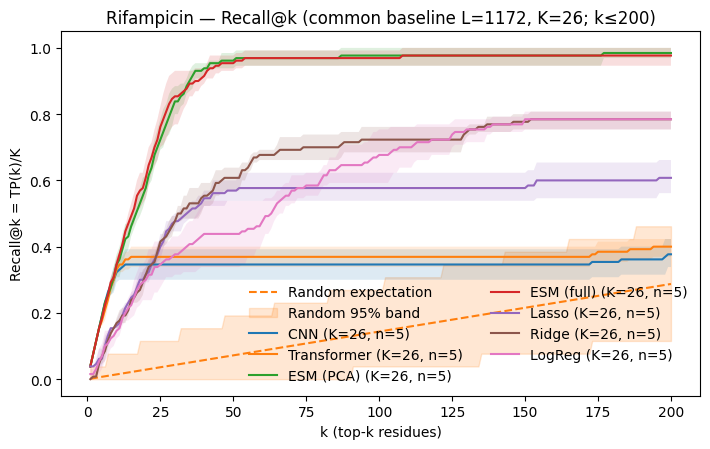

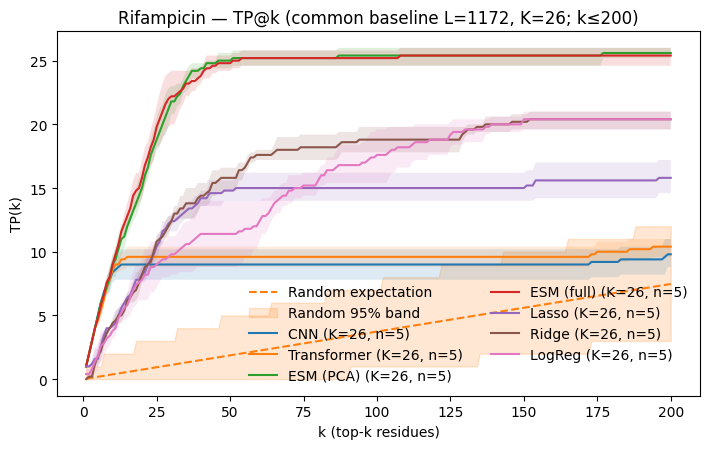

In [42]:
plot_per_drug_overlay(
    drug="rifampicin",
    model_keys=["cnn","transformer","esm_pca","esm_full","lasso","ridge","logreg"]
)

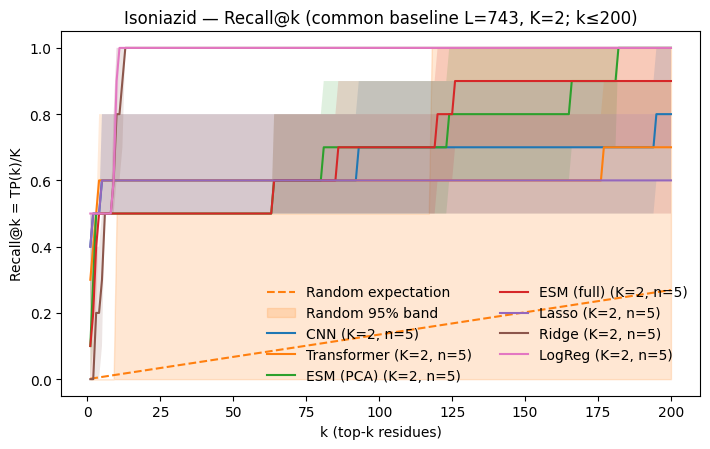

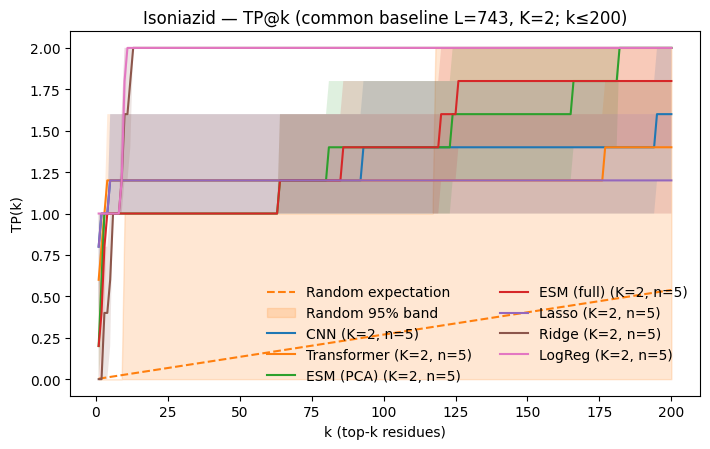

In [17]:
plot_per_drug_overlay(
    drug="isoniazid",
    model_keys=["cnn","transformer","esm_pca","esm_full","lasso","ridge","logreg"]
)

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict

# --- groups (match  Task 1) ---
FIRST_LINE = {"isoniazid", "rifampicin", "ethambutol", "pyrazinamide"}
SECOND_LINE = {"streptomycin", "amikacin", "capreomycin", 
                "moxifloxacin", "levofloxacin", "ethionamide"}

def drug_group(drug: str) -> str:
    d = str(drug).lower()
    if d in FIRST_LINE:  return "First line"
    if d in SECOND_LINE: return "Second line"
    return "Other"

# Optional pretty names for legends
MODEL_PRETTY = {
    "cnn":"CNN", "transformer":"Transformer",
    "esm_full":"ESM (full)", "esm_pca":"ESM (PCA)",
    "lasso":"Lasso", "ridge":"Ridge", "logreg":"LogReg"
}

# ============= Core: pooled recall =================
def pooled_recall_summary(
    model_keys,
    who_csv,
    drugs=None,
    mode="fractional",              # "fractional" or "fixed"
    q_list=(0.02, 0.05, 0.10, 0.20),# used if mode="fractional"
    k_list=(25, 50, 100, 200),      # used if mode="fixed"
    k_cap=200,                      # per-drug cap (consistent with  plots)
    n_boot=2000,
    seed=123
):
    rng = np.random.default_rng(seed)
    who_df = pd.read_csv(who_csv)

    # Collect per-drug, per-model, per-k recall (fold-mean)
    rows = []

    for model_key in model_keys:
        # infer_drugs_from_model is  helper; else pass `drugs`
        all_drugs = drugs or infer_drugs_from_model(model_key)
        for drug in all_drugs:
            # 1) load per-fold rankings
            fold_to_df, universe, genes_seen = collect_rankings_for_drug_model(drug, model_key)
            if not fold_to_df:  # no data
                continue

            # 2) WHO-based exclusions & filter rankings
            excl_norm = who_exclusions_for_drug_subset(who_df, drug, genes_seen)
            filtered_fold_to_df, allowed_union = {}, set()
            for fold, df in fold_to_df.items():
                tmp = df.copy()
                tmp["_gene_norm"] = tmp["gene"].astype(str).str.lower().str.strip()
                pairs = list(zip(tmp["_gene_norm"].to_numpy(), tmp["aa_pos"].astype(int).to_numpy()))
                keep = [pair not in excl_norm for pair in pairs]
                tmp = tmp.loc[keep, ["gene", "aa_pos", "score"]] \
                         .sort_values("score", ascending=False).reset_index(drop=True)
                if len(tmp) == 0: 
                    continue
                filtered_fold_to_df[fold] = tmp
                allowed_union |= set(zip(tmp["gene"].astype(str).str.lower().str.strip(),
                                         tmp["aa_pos"].astype(int)))
            if not filtered_fold_to_df:
                continue

            # 3) WHO gold hits intersected with filtered universe
            who_hits = who_hits_for_drug_subset(who_df, drug, genes_seen, allowed_union)
            K = len(who_hits)
            if K == 0:
                continue

            # 4) determine k grid for this drug–model
            min_len = min(len(df) for df in filtered_fold_to_df.values())
            k_max   = min(k_cap, min_len)
            if k_max < 1:
                continue

            if mode == "fractional":
                k_grid = sorted({max(1, int(np.floor(q * len(allowed_union)))) for q in q_list})
            else:  # fixed
                k_grid = [k for k in k_list if k <= k_max]
            if not k_grid:
                continue

            # 5) per-fold recall@k then mean across folds
            for k in k_grid:
                rec_vals = []
                for _, ranking_df in filtered_fold_to_df.items():
                    crv = tp_curve_for_fold(ranking_df, who_hits, k)  # returns TP_k and recall_k up to k
                    if not crv.empty:
                        rec_vals.append(float(crv["recall_k"].iloc[-1]))
                if not rec_vals:
                    continue
                rec_mean = float(np.mean(rec_vals))
                rows.append({
                    "drug": drug, "group": drug_group(drug),
                    "model": MODEL_PRETTY.get(model_key, model_key),
                    "k": k, "mode": mode,
                    "recall_mean_over_folds": rec_mean
                })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No data to summarize.")
        return None, None

    # === Pool across drugs: equal weight per drug ===
    # Compute group/model/k means over drugs and bootstrap CIs over drugs
    summary = []
    for (grp, mdl, k), sub in df.groupby(["group", "model", "k"]):
        # average per drug first (though each row is already per-drug mean over folds)
        drug_means = sub["recall_mean_over_folds"].to_numpy()
        m = float(drug_means.mean())
        # bootstrap over drugs
        boots = []
        for _ in range(n_boot):
            samp = rng.choice(drug_means, size=len(drug_means), replace=True)
            boots.append(float(np.mean(samp)))
        lo, hi = np.percentile(boots, [2.5, 97.5])
        summary.append({"group": grp, "model": mdl, "k": k, "mean_recall": m,
                        "ci_lo": lo, "ci_hi": hi, "n_drugs": len(drug_means)})
    summary = pd.DataFrame(summary)
    return df, summary

# ============= Plotters ===========================
def plot_pooled_recall(summary, mode="fractional"):
    # One panel per k; within each, show two groups with points for each model
    ks = sorted(summary["k"].unique())
    for k in ks:
        sub = summary[summary["k"] == k].copy()
        # consistent y ordering: models alphabetical
        models = sorted(sub["model"].unique())
        ymap = {m: i for i, m in enumerate(models)}
        fig, ax = plt.subplots(figsize=(7, 5))
        for grp, xoff in [("First line", -0.08), ("Second line", 0.08)]:
            sg = sub[sub["group"] == grp]
            for _, row in sg.iterrows():
                y = ymap[row["model"]] + (0.35 if grp=="Second line" else -0.35)  # slight jitter by group
                ax.errorbar(row["mean_recall"], y,
                            xerr=[[row["mean_recall"] - row["ci_lo"]],
                                  [row["ci_hi"] - row["mean_recall"]]],
                            fmt="o", label=f"{grp}" if grp not in ax.get_legend_handles_labels()[1] else "")
        ax.set_yticks([ymap[m] for m in models])
        ax.set_yticklabels(models)
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel("Pooled mean Recall@k (±95% CI)")
        label_k = f"{int(k)}" if mode=="fixed" else f"{k} residues"
        ax.set_title(f"Pooled recall@k (k={label_k}) by model and drug group")
        ax.legend(frameon=False, loc="lower right")
        plt.tight_lat(); plt.show()


In [ ]:
# # Fractional budgets (recommended)
# _, summ = pooled_recall_summary(
#     model_keys=["cnn","transformer","esm_pca","esm_full","lasso","ridge","logreg"],
#     who_csv=WHO_CSV,
#     mode="fractional",
#     q_list=(0.02, 0.05, 0.10, 0.20)  # 2%, 5%, 10%, 20% of filtered L
# )
# plot_pooled_recall(summ, mode="fractional")

# Or: fixed k values (if  want a direct “top-50/100” view)
_, summ_fixed = pooled_recall_summary(
    model_keys=["cnn","transformer","esm_pca","esm_full","lasso","ridge","logreg"],
    who_csv=WHO_CSV,
    mode="fixed",
    k_list=(25, 50, 100, 200)
)
plot_pooled_recall(summ_fixed, mode="fixed")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- pretty-name mapping used when building the pooled summary ---
MODEL_PRETTY = {
    "cnn":"CNN", "transformer":"Transformer",
    "esm_full":"ESM (full)", "esm_pca":"ESM (PCA)",
    "lasso":"Lasso", "ridge":"Ridge", "logreg":"LogReg"
}
# --- y-order & colors in the AUC-style plot ---
MODEL_ORDER = [
    "Transformer", "Ridge", "LogReg", "Lasso",
    "ESM (PCA)", "ESM (full)", "CNN"
]

MODEL_COLOR = {
    "CNN":         "teal",
    "ESM (full)":  "blue",        # take the old CNN-320 color
    "ESM (PCA)": "lightblue",   # take the old CNN-PCA10 color
    "Lasso":       "gray",
    "LogReg":      "black",
    "Ridge":       "dimgray",
    "Transformer": "pink",
}



def plot_pooled_recall_panel_like_auc(summary, k_sel, xlim=(0.0, 1.0),
                                      group_order=("Second line","First line"),
                                      title="Pooled mean Recall@k ± 95% CI"):
    """
    summary: DataFrame with columns ['group','model','k','mean_recall','ci_lo','ci_hi','n_drugs']
    k_sel  : integer (fixed k) or the exact k used in fractional mode (the function just filters on k)
    """
    # keep only the requested k
    sub = summary[summary["k"] == k_sel].copy()
    if sub.empty:
        print(f"[plot] nothing to plot for k={k_sel}")
        return

    # build y positions exactly like  AUC panel:
    yticks, ylabels = [], []
    y_pos = 0
    rows_to_plot = []  # (mean, lo, hi, y, model, group)
    sep_after_first_group_y = None

    for grp in group_order[::-1]:  # to put Second line on top like  figure
        gdf = sub[sub["group"] == grp]
        for mdl in MODEL_ORDER:
            r = gdf[gdf["model"] == mdl]
            if r.empty:  # skip missing model/group combos
                continue
            m  = float(r["mean_recall"].iloc[0])
            lo = float(r["ci_lo"].iloc[0])
            hi = float(r["ci_hi"].iloc[0])
            rows_to_plot.append((m, lo, hi, y_pos, mdl, grp))
            yticks.append(y_pos)
            ylabels.append(mdl)
            y_pos += 1
        # spacer between groups
        if grp == "First line":
            sep_after_first_group_y = y_pos - 0.5
        y_pos += 1

    fig, ax = plt.subplots(figsize=(9, 5.5))

    seen_models = set()
    for m, lo, hi, y, mdl, grp in rows_to_plot:
        ax.errorbar(m, y,
                    xerr=[[m - lo], [hi - m]],
                    fmt="o", markersize=6,
                    color=MODEL_COLOR.get(mdl, "black"),
                    label=mdl if mdl not in seen_models else None)
        seen_models.add(mdl)

    # axes formatting to mimic  AUC panel
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xlim(*xlim)
    ax.set_xlabel("Pooled mean Recall@k")
    ax.set_title(title if isinstance(k_sel, str) else f"{title}  (k={k_sel})")

    # horizontal separator between groups
    if sep_after_first_group_y is not None:
        ax.axhline(y=sep_after_first_group_y, color="lightgray", linestyle="--")

    # legend matching  AUC panel
    ax.legend(title="Models", loc="upper right", frameon=True)
    plt.tight_lat()
    plt.show()


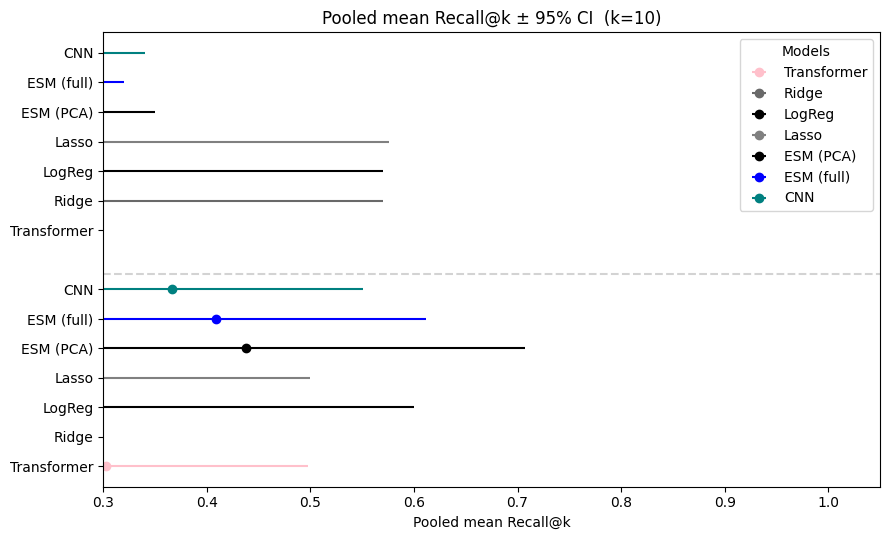

In [ ]:
# get pooled recall summary at fixed k
_, recall_summary = pooled_recall_summary(
    model_keys=["cnn","transformer","esm_pca","esm_full","lasso","ridge","logreg"],  # or  internal keys mapped to these names
    who_csv=WHO_CSV,
    mode="fixed",
    k_list=(10,)  # choose 25, 50, 100, ...
)

# make the panel for k=25
plot_pooled_recall_panel_like_auc(
    recall_summary, 
    k_sel=10, 
    xlim=(0.3, 1.05),
    title="Pooled mean Recall@k ± 95% CI"
)


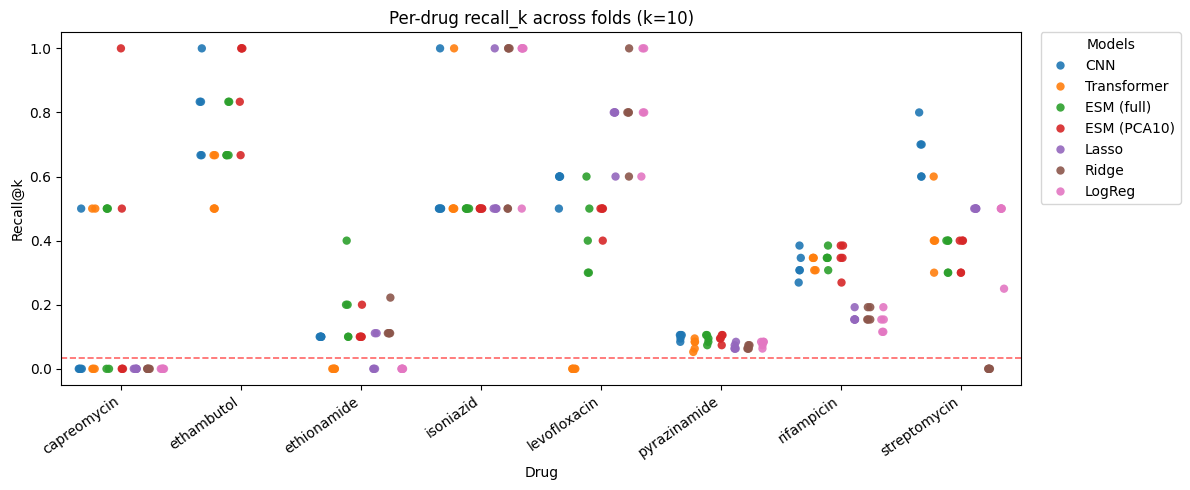

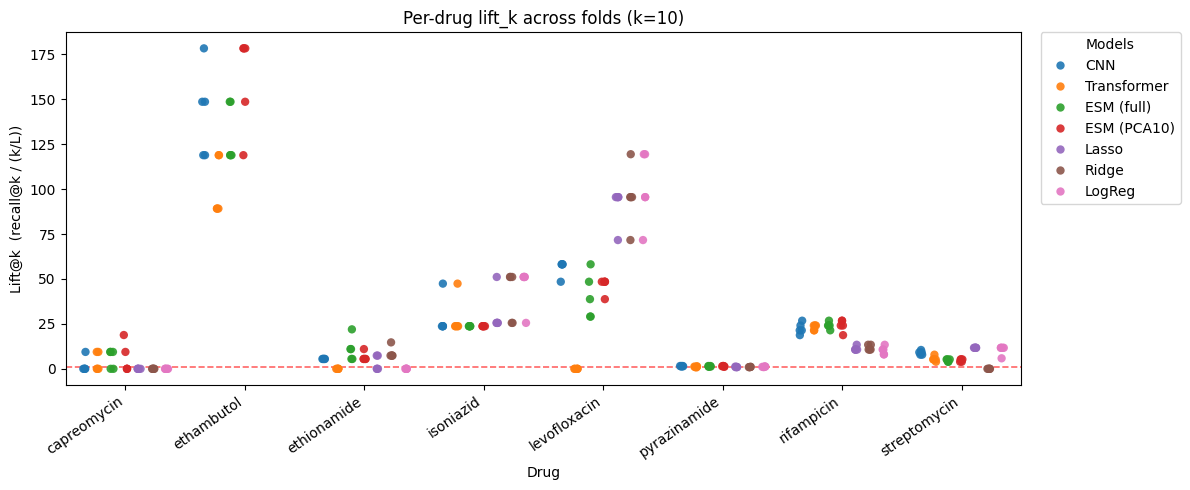

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# ---- knobs ----
WHO_CSV = "data/filtered_variants_output.csv"
MODEL_KEYS = ["cnn","transformer","esm_full","esm_pca","lasso","ridge","logreg"]
K_MODE = "fixed"     # "fixed" or "fractional"
K_FIXED = 10         # used if K_MODE == "fixed"
Q = 0.05             # used if K_MODE == "fractional" (k = floor(Q * L_filtered))
K_CAP = 200

# (pretty names for legend)
MODEL_NAME = {
    "cnn":"CNN", "transformer":"Transformer",
    "esm_full":"ESM (full)", "esm_pca":"ESM (PCA10)",
    "lasso":"Lasso", "ridge":"Ridge", "logreg":"LogReg"
}

def per_fold_recall_table(model_keys=MODEL_KEYS, who_csv=WHO_CSV,
                          k_mode=K_MODE, k_fixed=K_FIXED, q=Q, k_cap=K_CAP):
    who_df = pd.read_csv(who_csv)
    rows = []
    for model_key in model_keys:
        drugs = infer_drugs_from_model(model_key)  #  helper
        for drug in drugs:
            # 1) load per-fold rankings
            fold_to_df, universe, genes_seen = collect_rankings_for_drug_model(drug, model_key)
            if not fold_to_df: 
                continue

            # 2) filter out uncertain / non-intersectional WHO sites from the search space
            excl_norm = who_exclusions_for_drug_subset(who_df, drug, genes_seen)
            filtered = {}
            allowed_union = set()
            for fold, df in fold_to_df.items():
                t = df.copy()
                t["_gene_norm"] = t["gene"].astype(str).str.lower().str.strip()
                pairs = list(zip(t["_gene_norm"].to_numpy(), t["aa_pos"].astype(int).to_numpy()))
                keep = [pair not in excl_norm for pair in pairs]
                t = t.loc[keep, ["gene","aa_pos","score"]].sort_values("score", ascending=False).reset_index(drop=True)
                if len(t) == 0: 
                    continue
                filtered[fold] = t
                allowed_union |= set(zip(t["gene"].astype(str).str.lower().str.strip(),
                                         t["aa_pos"].astype(int)))
            if not filtered:
                continue

            # 3) WHO “gold” hits restricted to this filtered universe
            who_hits = who_hits_for_drug_subset(who_df, drug, genes_seen, allowed_union)
            K = len(who_hits)
            if K == 0:
                continue

            # 4) choose k
            min_len = min(len(df) for df in filtered.values())
            k_max = min(k_cap, min_len)
            if k_max < 1:
                continue
            if k_mode == "fractional":
                k = max(1, int(np.floor(q * len(allowed_union))))
            else:
                k = min(k_fixed, k_max)

            # 5) per-fold recall@k
            L = len(allowed_union)                # filtered search space
            recall_rand = k / float(L)            # random baseline (expected recall)
            for fold, ranking_df in filtered.items():
                crv = tp_curve_for_fold(ranking_df, who_hits, k)  # up to k
                if crv.empty: 
                    continue
                rec = float(crv["recall_k"].iloc[-1])
                rows.append({
                    "drug": drug,
                    "model": MODEL_NAME.get(model_key, model_key),
                    "fold": fold,
                    "k": k, "L": L, "K": K,
                    "recall_k": rec,
                    "lift_k": rec / recall_rand if recall_rand > 0 else np.nan
                })
    return pd.DataFrame(rows)

def plot_per_drug_scatter(df, metric="recall_k"):
    # same style as  AUC panel: dots per fold, grouped by drug, colored by model
    plt.figure(figsize=(12,5))
    ax = sns.stripplot(
        data=df, x="drug", y=metric, hue="model",
        jitter=True, dodge=True, size=6, alpha=0.9
    )
    if metric == "lift_k":
        ax.axhline(1.0, ls="--", color="red", alpha=0.6, lw=1.2)   # random baseline for lift
        ax.set_ylabel("Lift@k  (recall@k / (k/L))")
    else:
        ax.set_ylabel("Recall@k")
        # optional: show overall mean random baseline (mean of k/L across drugs)
        mean_rand = (df["k"]/df["L"]).mean()
        ax.axhline(mean_rand, ls="--", color="red", alpha=0.6, lw=1.2)
    ax.set_xlabel("Drug")
    ax.set_title(f"Per-drug {metric} across folds (k={int(df['k'].mode()[0])})")
    ax.legend(title="Models", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.xticks(rotation=35, ha="right")
    plt.tight_lat(); plt.show()

# ===== run =====
df = per_fold_recall_table()
plot_per_drug_scatter(df, metric="recall_k")  # raw recall@k
plot_per_drug_scatter(df, metric="lift_k")    # preferred “chance-normalized” view


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# define the drug groups (use  project’s canonical names)
FIRST_LINE  = ["isoniazid", "rifampicin", "ethambutol", "pyrazinamide"]
SECOND_LINE = ["streptomycin", "amikacin", "capreomycin", "moxifloxacin", "levofloxacin",
               "ethionamide"]

# (optional) consistent colors per model
MODEL_COLOR = {
    "CNN":         "teal",
    "ESM (full)":  "blue",
    "ESM (PCA10)": "lightblue",
    "Lasso":       "gray",
    "LogReg":      "black",
    "Ridge":       "dimgray",
    "Transformer": "pink",
}

def plot_lift_grouped(df_lift, palette=MODEL_COLOR):
    df = df_lift.copy()

    # --- build x-order: first-line → second-line → any remaining drugs
    present = list(df["drug"].unique())
    first   = [d for d in FIRST_LINE  if d in present]
    second  = [d for d in SECOND_LINE if d in present]
    others  = [d for d in present if d not in first + second]
    order   = first + second + others

    df["drug"] = pd.Categorical(df["drug"], categories=order, ordered=True)

    # --- plot
    plt.figure(figsize=(14,5))
    ax = sns.stripplot(
        data=df, x="drug", y="lift_k", hue="model",
        dodge=True, jitter=True, size=6, alpha=0.9,
        palette=palette
    )
    # chance line for Lift
    ax.axhline(1.0, ls="--", color="red", alpha=0.6, lw=1.2)

    ax.set_ylabel("Lift@k  (recall@k / (k/L))")
    ax.set_xlabel("Drug")
    k_val = int(df["k"].mode().iloc[0]) if not df["k"].empty else "k"
    ax.set_title(f"Per-drug Lift@k across folds (k={k_val})")
    plt.xticks(rotation=35, ha="right")

    # --- light visual separators + labels
    ymax = ax.get_ylim()[1]
    if len(first) > 0 and (len(second) > 0 or len(others) > 0):
        sep_x = len(first) - 0.5
        ax.axvline(sep_x, color="lightgray", ls="--", lw=1)
        ax.text((len(first)-1)/2, ymax*0.98, "First line", ha="center", va="top", fontsize=11)
        if len(second) > 0:
            ax.text(len(first) + (len(second)-1)/2, ymax*0.98, "Second line", ha="center", va="top", fontsize=11)

    ax.legend(title="Models", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_lat(); plt.show()


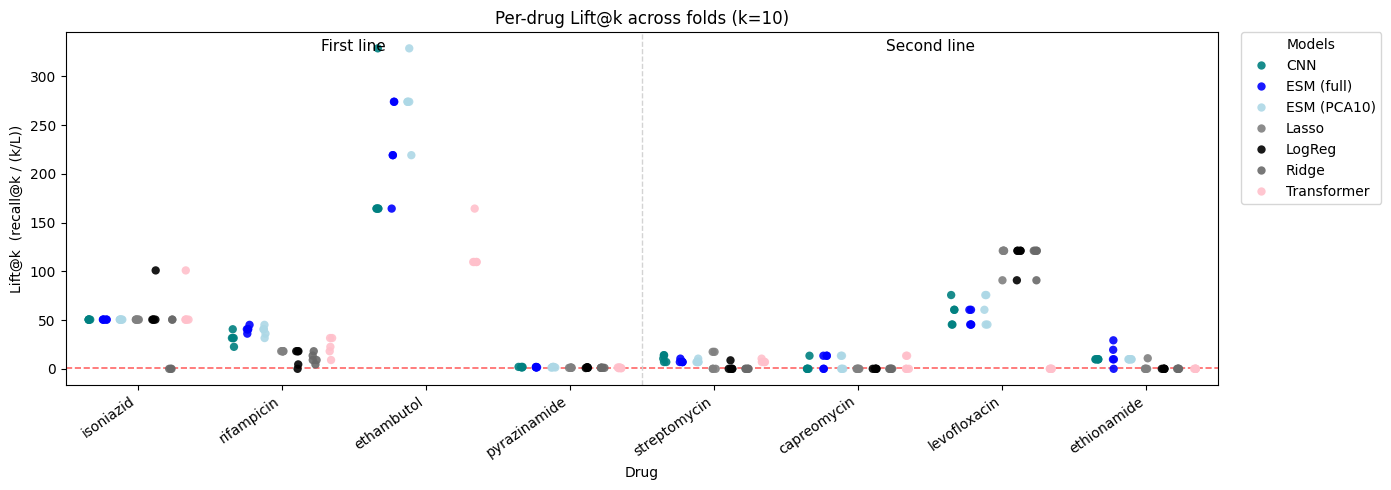

In [35]:
plot_lift_grouped(df)

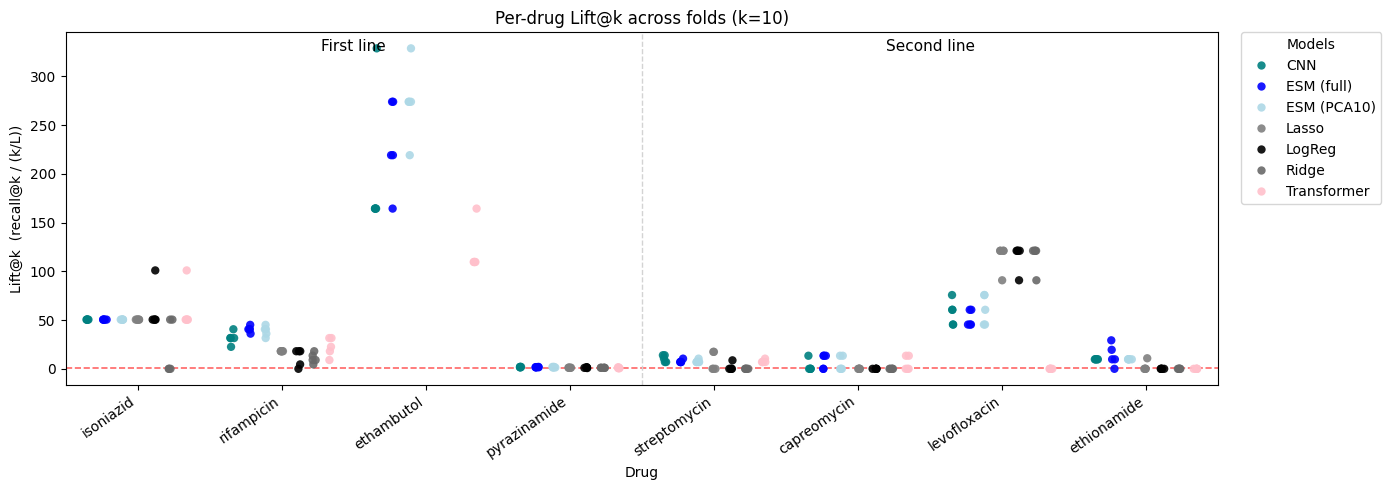

In [36]:
keep = set(FIRST_LINE) | set(SECOND_LINE)
plot_lift_grouped(df[df["drug"].isin(keep)])


In [ ]:
import numpy as np, pandas as pd

FIRST_LINE  = ["isoniazid","rifampicin","ethambutol","pyrazinamide"]
SECOND_LINE = ["streptomycin","amikacin","capreomycin","moxifloxacin","levofloxacin","ethionamide"]

def add_groups(df):
    def grp(d):
        if d in FIRST_LINE: return "First line"
        if d in SECOND_LINE: return "Second line"
        return "Other"
    out = df.copy()
    out["group"] = out["drug"].map(grp)
    out["rand_recall"] = out["k"] / out["L"]
    out["above_random"] = (out["recall_k"] > out["rand_recall"]).astype(int)
    return out

def hier_bootstrap_mean(df, n_boot=5000, seed=7):
    """Bootstrap over drugs, then over folds within drugs (per model, per group)."""
    rng = np.random.default_rng(seed)
    out = []
    for (g, m), sub in df.groupby(["group","model"]):
        drugs = sub["drug"].unique()
        if len(drugs) == 0:
            continue
        boots = []
        for _ in range(n_boot):
            # sample drugs with replacement
            samp_drugs = rng.choice(drugs, size=len(drugs), replace=True)
            vals = []
            for d in samp_drugs:
                sub_d = sub[sub["drug"]==d]
                folds = sub_d["fold"].unique()
                # sample folds with replacement
                samp_folds = rng.choice(folds, size=len(folds), replace=True)
                vals.append(sub_d[sub_d["fold"].isin(samp_folds)]["recall_k"].mean())
            boots.append(np.mean(vals))
        boots = np.array(boots)
        out.append({
            "group": g, "model": m,
            "mean": sub["recall_k"].mean(),
            "ci_lo": np.quantile(boots, 0.025),
            "ci_hi": np.quantile(boots, 0.975),
            "n_drugs": len(drugs)
        })
    return pd.DataFrame(out).sort_values(["group","mean"], ascending=[True,False])

def wins_by_drug(df):
    """Which model has the highest per-drug mean recall@k (break ties = multi-win)."""
    per = (df.groupby(["drug","model"])["recall_k"].mean()
             .reset_index().rename(columns={"recall_k":"mean_recall"}))
    per["group"] = per["drug"].map(lambda d: "First line" if d in FIRST_LINE
                                              else "Second line" if d in SECOND_LINE
                                              else "Other")
    winners = []
    for d, sub in per.groupby("drug"):
        mx = sub["mean_recall"].max()
        winners += list(sub.loc[sub["mean_recall"]==mx, ["drug","group","model"]].to_dict("records"))
    wdf = pd.DataFrame(winners)
    return (wdf.groupby(["group","model"]).size()
              .reset_index(name="#drugs_won")
              .sort_values(["group","#drugs_won"], ascending=[True,False]))

def frac_above_random(df):
    """Fraction of fold points above random baseline, per model & group."""
    return (df.groupby(["group","model"])["above_random"]
              .mean().reset_index()
              .rename(columns={"above_random":"frac_folds_above_random"})
              .sort_values(["group","frac_folds_above_random"], ascending=[True,False]))

def pairwise_prob_A_gt_B(df, group="First line", n_boot=5000, seed=13):
    """P(A>B): probability model A’s hierarchical-bootstrapped mean > B’s, within a group."""
    rng = np.random.default_rng(seed)
    # prep: split by model
    group_df = df[df["group"]==group]
    per_model = {m: md for m, md in group_df.groupby("model")}
    models = sorted(per_model.keys())
    # precompute bootstrap samples per model
    def boot_samples(sub):
        drugs = sub["drug"].unique()
        boots=[]
        for _ in range(n_boot):
            samp_drugs = rng.choice(drugs, size=len(drugs), replace=True)
            vals=[]
            for d in samp_drugs:
                sd = sub[sub["drug"]==d]
                folds = sd["fold"].unique()
                samp_folds = rng.choice(folds, size=len(folds), replace=True)
                vals.append(sd[sd["fold"].isin(samp_folds)]["recall_k"].mean())
            boots.append(np.mean(vals))
        return np.array(boots)
    boots = {m: boot_samples(md) for m, md in per_model.items()}
    rows=[]
    for i, a in enumerate(models):
        for b in models[i+1:]:
            pab = float((boots[a] > boots[b]).mean())
            rows.append({"group":group, "A":a, "B":b, "P(A>B)":pab})
    return pd.DataFrame(rows).sort_values(["group","P(A>B)"], ascending=[True,False])

# === run on  per-fold table `df` ===
dfg = add_groups(df)

summary_ci  = hier_bootstrap_mean(dfg)
winners     = wins_by_drug(dfg)
above_rand  = frac_above_random(dfg)
pair_first  = pairwise_prob_A_gt_B(dfg, group="First line")
pair_second = pairwise_prob_A_gt_B(dfg, group="Second line")

print("Pooled mean recall@k ±95% CI (hierarchical bootstrap):")
display(summary_ci)
print("\n# drugs where a model is best (ties count for all tied):")
display(winners)
print("\nFraction of folds above random baseline:")
display(above_rand)
print("\nPairwise P(A>B) within First line:")
display(pair_first)
print("\nPairwise P(A>B) within Second line:")
display(pair_second)


Pooled mean recall@k ±95% CI (hierarchical bootstrap):


,group,model,mean,ci_lo,ci_hi,n_drugs
1,First line,ESM (PCA10),0.460223,0.195614,0.756951,4
0,First line,CNN,0.455506,0.200439,0.722222,4
2,First line,ESM (full),0.418030,0.192763,0.645833,4
6,First line,Transformer,0.393306,0.188486,0.590278,4
4,First line,LogReg,0.374683,0.078655,0.888889,3
5,First line,Ridge,0.345533,0.068129,0.777778,3
3,First line,Lasso,0.277004,0.070175,0.583333,3
7,Second line,CNN,0.365000,0.097917,0.635417,4
10,Second line,Lasso,0.326111,0.018519,0.637500,4
11,Second line,LogReg,0.322500,0.000000,0.679271,4



# drugs where a model is best (ties count for all tied):


,group,model,#drugs_won
1,First line,ESM (PCA10),2
0,First line,CNN,1
2,First line,ESM (full),1
3,First line,LogReg,1
6,Second line,ESM (full),2
4,Second line,CNN,1
5,Second line,ESM (PCA10),1
7,Second line,LogReg,1



Fraction of folds above random baseline:


,group,model,frac_folds_above_random
0,First line,CNN,1.000000
1,First line,ESM (PCA10),1.000000
2,First line,ESM (full),1.000000
4,First line,LogReg,0.933333
6,First line,Transformer,0.900000
3,First line,Lasso,0.800000
5,First line,Ridge,0.800000
9,Second line,ESM (full),0.900000
8,Second line,ESM (PCA10),0.850000
7,Second line,CNN,0.800000



Pairwise P(A>B) within First line:


,group,A,B,P(A>B)
2,First line,CNN,Lasso,0.8214
7,First line,ESM (PCA10),Lasso,0.8184
11,First line,ESM (full),Lasso,0.7876
9,First line,ESM (PCA10),Ridge,0.6936
4,First line,CNN,Ridge,0.6930
13,First line,ESM (full),Ridge,0.6504
8,First line,ESM (PCA10),LogReg,0.6392
10,First line,ESM (PCA10),Transformer,0.6334
5,First line,CNN,Transformer,0.6328
3,First line,CNN,LogReg,0.6324



Pairwise P(A>B) within Second line:


,group,A,B,P(A>B)
14,Second line,ESM (full),Transformer,0.9330
10,Second line,ESM (PCA10),Transformer,0.9006
5,Second line,CNN,Transformer,0.8970
17,Second line,Lasso,Transformer,0.8194
19,Second line,LogReg,Transformer,0.7994
4,Second line,CNN,Ridge,0.7290
13,Second line,ESM (full),Ridge,0.7150
9,Second line,ESM (PCA10),Ridge,0.6900
16,Second line,Lasso,Ridge,0.6600
18,Second line,LogReg,Ridge,0.6490
